In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder,StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_val_score,StratifiedKFold
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, RocCurveDisplay, classification_report, roc_auc_score,make_scorer, accuracy_score, confusion_matrix
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
import joblib
import optuna
from sklearn.cluster import KMeans
# import XPER
import seaborn as sns
# from XPER.viz.Visualisation import visualizationClass as viz
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
import lime
import lime.lime_tabular
import shap
import warnings
from typing import Tuple
from scipy.stats import chi2_contingency

# loading data

In [ ]:
def load_data(file_path='Data/dataproject2025.csv'):
    df = pd.read_csv(file_path, index_col=0)
    #df = df.dropna()
    df = df.astype({col: "category" for col in df.select_dtypes(include="object").columns})
    X = df.drop(columns=['target','Predictions','Predicted probabilities'])
    Y = df[['target','Predictions','Predicted probabilities']]

    return X, Y

X, Y = load_data()
full_df = pd.concat([X, Y], axis=1)
og_df = pd.concat([X,Y['target']], axis=1)
withDP_df = pd.concat([X,Y['Predicted probabilities']], axis=1)

In [5]:
full_df.head(5)
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1086236 entries, 0 to 1086682
Data columns (total 38 columns):
 #   Column                   Non-Null Count    Dtype   
---  ------                   --------------    -----   
 0   issue_d                  1086236 non-null  int64   
 1   loan duration            1086236 non-null  int64   
 2   annual_inc               1086236 non-null  float64 
 3   avg_cur_bal              1086236 non-null  float64 
 4   bc_open_to_buy           1086236 non-null  float64 
 5   bc_util                  1086236 non-null  float64 
 6   delinq_2yrs              1086236 non-null  float64 
 7   dti                      1086236 non-null  float64 
 8   emp_length               1086236 non-null  category
 9   emp_title                1086236 non-null  category
 10  fico_range_high          1086236 non-null  float64 
 11  funded_amnt              1086236 non-null  float64 
 12  grade                    1086236 non-null  category
 13  home_ownership           1086236

For the necessity of stability analysis we need to keep fresh "future" data to test, we thus need to split the datasets.

In [6]:

# first train / validation
og_df_train_1 = og_df[(og_df["issue_d"] >= 2012) & (og_df["issue_d"] <= 2015)].copy()
og_df_val_1   = og_df[og_df["issue_d"] == 2016].copy()

# stability dataset
og_df_train_stab = og_df[(og_df["issue_d"] >= 2017) & (og_df["issue_d"] <= 2018)].copy()
og_df_test_stab  = og_df[(og_df["issue_d"] >= 2019) & (og_df["issue_d"] <= 2020)].copy()

# checking there are not too big differences in default percentage
for name, df in [("train_1", og_df_train_1),
                 ("val_1", og_df_val_1),
                 ("train_stab", og_df_train_stab),
                 ("test_stab", og_df_test_stab)]:
    total = len(df)
    n1 = df["target"].sum()
    prop = n1 / total * 100
    print(f"{name}: {total} rows, {n1} defaults ({prop:.2f}%)")


train_1: 524431 rows, 104809 defaults (19.99%)
val_1: 258793 rows, 54372 defaults (21.01%)
train_stab: 268814 rows, 63754 defaults (23.72%)
test_stab: 34198 rows, 5713 defaults (16.71%)


# Prediction performance benchmark


In [7]:
full_df_val_1   = full_df[full_df["issue_d"] == 2016].copy()
y_true_2016 = full_df_val_1['target']
y_pred_unkwnown_model_2016 = full_df_val_1['Predictions']
y_prob_unknown_model_2016 = full_df_val_1['Predicted probabilities']  # for AUC


accuracy_unknown_model_2016 = accuracy_score(y_true_2016, y_pred_unkwnown_model_2016)
print(f"Accuracy of the unknown model on 2016 data : {accuracy_unknown_model_2016:.4f}")

auc_unknown_model_2016 = roc_auc_score(y_true_2016, y_prob_unknown_model_2016)
print(f"AUC of the unknown model on 2016 data : {auc_unknown_model_2016:.4f}")

# Compute P&L
pred_non_default = full_df_val_1['Predictions'] == 0
df_lend = full_df_val_1[pred_non_default]

loan_years = df_lend['loan duration'].apply(lambda x: 3 if x == 0 else 5)
int_rate_dec = df_lend['int_rate'] / 100

total_pnl_unknown_model_2016 = np.where(
    df_lend['target'] == 0,
    df_lend['funded_amnt'] * int_rate_dec * loan_years,  # interest earned
    -df_lend['funded_amnt']  # principal lost
).sum()

print(f"Total P&L unknown model on 2016 data: ${total_pnl_unknown_model_2016:,.0f}")

Accuracy of the unknown model on 2016 data : 0.7706
AUC of the unknown model on 2016 data : 0.7109
Total P&L unknown model on 2016 data: $475,106,739


In [8]:
full_df_val_2 = full_df[(full_df["issue_d"] >= 2019) & (full_df["issue_d"] <= 2020)].copy()

y_true_201920 = full_df_val_2['target']
y_pred_unkwnown_model_201920 = full_df_val_2['Predictions']
y_prob_unknown_model_201920 = full_df_val_2['Predicted probabilities']  # for AUC


accuracy_unknown_model_201920 = accuracy_score(y_true_201920, y_pred_unkwnown_model_201920)
print(f"Accuracy of the unknown model on 2019-2020 data : {accuracy_unknown_model_201920:.4f}")

auc_unknown_model_201920 = roc_auc_score(y_true_201920, y_prob_unknown_model_201920)
print(f"AUC of the unknown model on 2019-2020 data : {auc_unknown_model_201920:.4f}")

# Compute P&L
pred_non_default = full_df_val_2['Predictions'] == 0
df_lend = full_df_val_2[pred_non_default]

loan_years = df_lend['loan duration'].apply(lambda x: 3 if x == 0 else 5)
int_rate_dec = df_lend['int_rate'] / 100

total_pnl_unknown_model_201920 = np.where(
    df_lend['target'] == 0,
    df_lend['funded_amnt'] * int_rate_dec * loan_years,  # interest earned
    -df_lend['funded_amnt']  # principal lost
).sum()

print(f"Total P&L unknown model on 2019-2020 data: ${total_pnl_unknown_model_201920:,.0f}")

Accuracy of the unknown model on 2019-2020 data : 0.7984
AUC of the unknown model on 2019-2020 data : 0.6869
Total P&L unknown model on 2019-2020 data: $109,497,080


# Step 1 : Global surrogate on unknown model

## Linear regression

Linear Regression Surrogate R² on test set: 0.9643
Linear regression Surrogate MSE on test set: 0.000464


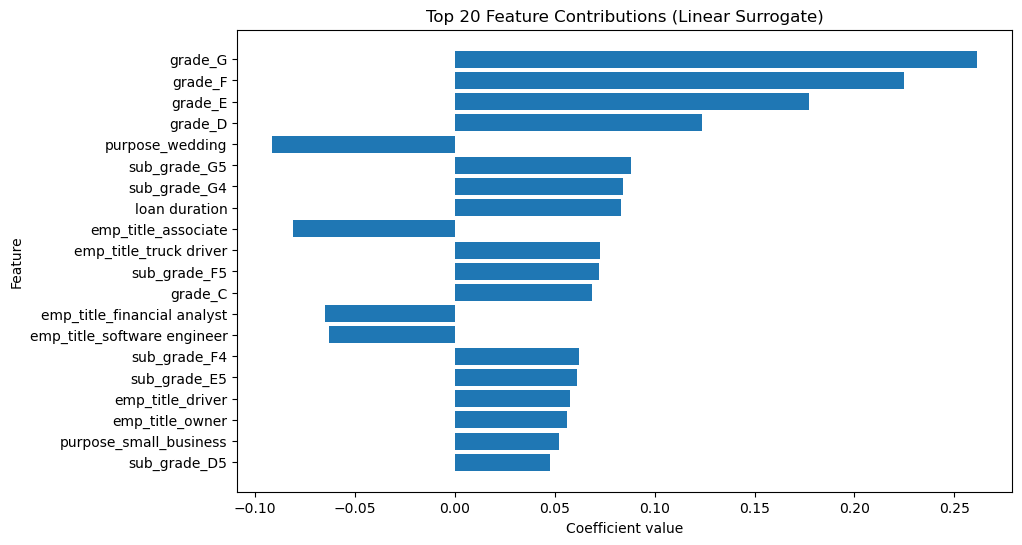

In [9]:

# Selecting appropriate time period to compare later with surrogate models of our algorithm

withDP_df_train_1 = withDP_df[(withDP_df["issue_d"] >= 2012) & (withDP_df["issue_d"] <= 2015)].copy()
withDP_df_val_1   = withDP_df[withDP_df["issue_d"] == 2016].copy()

# Preparing training and test sets

X_train = withDP_df_train_1.drop(columns=['Predicted probabilities'])
y_train = withDP_df_train_1['Predicted probabilities']

X_test = withDP_df_val_1.drop(columns=['Predicted probabilities'])
y_test = withDP_df_val_1['Predicted probabilities']

# Preprocessing for linear regression
num_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
bool_cols = [col for col in num_cols if X[col].nunique() == 2]
num_cols_to_scale = [col for col in num_cols if col not in bool_cols]
cat_cols = X.select_dtypes(include=['category']).columns.tolist()

preprocessor_surrogate_unknown_model = ColumnTransformer([
    ('num', StandardScaler(), num_cols_to_scale),    
    ('bool', 'passthrough', bool_cols),            
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])


X_train_processed = preprocessor_surrogate_unknown_model.fit_transform(X_train)
X_test_processed = preprocessor_surrogate_unknown_model.transform(X_test)

# training model
surrogate_linear_unknown_model = LinearRegression()
surrogate_linear_unknown_model.fit(X_train_processed, y_train)

# Predicting and computing surrogate model proximity to unknown model 
y_pred_unkwnown_model = surrogate_linear_unknown_model.predict(X_test_processed)
r2 = r2_score(y_test, y_pred_unkwnown_model)
mse = mean_squared_error(y_test, y_pred_unkwnown_model)
print(f"Linear Regression Surrogate R² on test set: {r2:.4f}")
print(f"Linear regression Surrogate MSE on test set: {mse:.6f}")

# Plotting feature contributions through coefficients
num_features = num_cols_to_scale
bool_features = bool_cols
cat_features = preprocessor_surrogate_unknown_model.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
feature_names = num_features + bool_features + cat_features

coefficients = surrogate_linear_unknown_model.coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coef': np.abs(coefficients)
}).sort_values(by='abs_coef', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(coef_df['feature'][:20][::-1], coef_df['coefficient'][:20][::-1])
plt.xlabel('Coefficient value')
plt.ylabel('Feature')
plt.title('Top 20 Feature Contributions (Linear Surrogate)')
plt.show()


## Decision Tree Regressor

Decision Tree Surrogate R² on test set: 0.7355
Decision Tree Surrogate MSE on test set: 0.003437


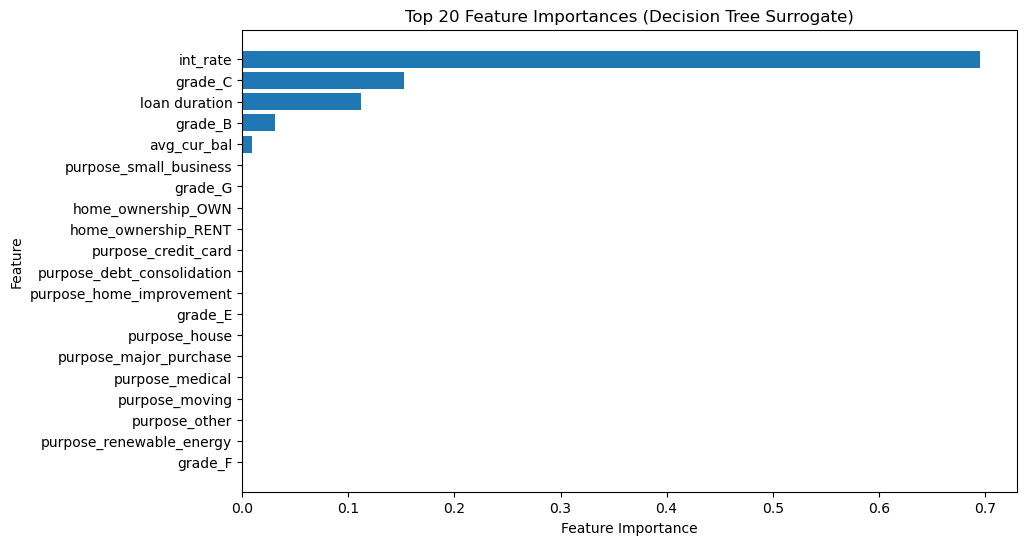

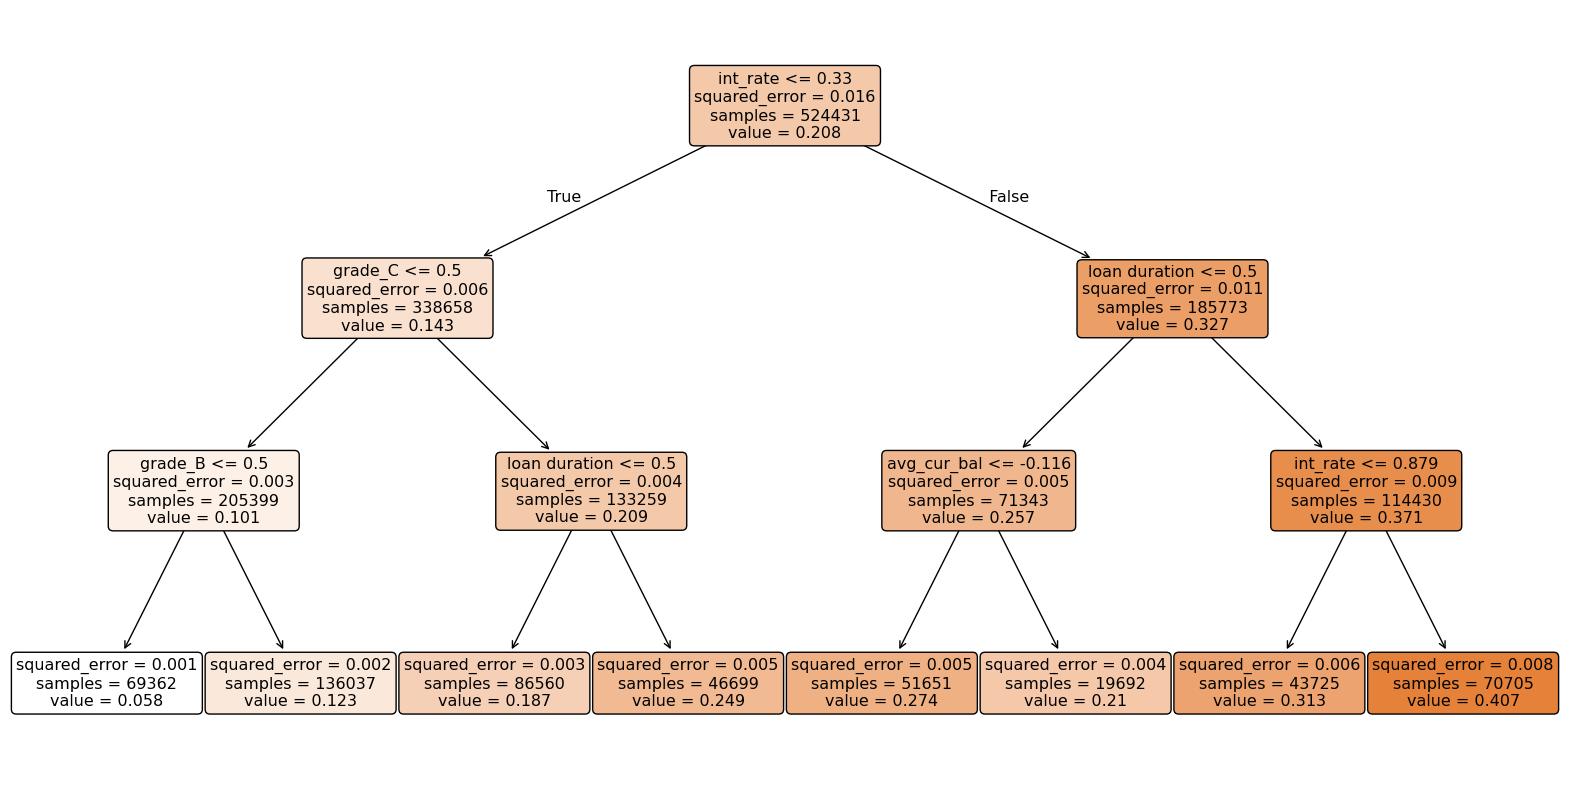

In [10]:
# training model
surrogate_tree_unknown_model = DecisionTreeRegressor(max_depth=3, random_state=8)
surrogate_tree_unknown_model.fit(X_train_processed, y_train)

# Predicting and computing surrogate model proximity to unknown model 
y_pred_tree = surrogate_tree_unknown_model.predict(X_test_processed) 
r2_tree = r2_score(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
print(f"Decision Tree Surrogate R² on test set: {r2_tree:.4f}")
print(f"Decision Tree Surrogate MSE on test set: {mse_tree:.6f}")

# Plotting feature importances

importances = surrogate_tree_unknown_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'][:20][::-1], importance_df['importance'][:20][::-1])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances (Decision Tree Surrogate)')
plt.show()

plt.figure(figsize=(20,10))
plot_tree(surrogate_tree_unknown_model, feature_names=feature_names, filled=True, rounded=True, max_depth=3)
plt.show()

We can see that, according to the global surrogate linear regression model, the grade feature is overall the largest contributor to the prediction. Interestingly, the surrogate decision tree model provides a different interpretation by showing the interest rate feature as the most decisive. It is not surprising that these two surrogate models may yield different results in terms of feature importance, since linear models capture global linear relationships, while trees can capture local non-linear interactions. Therefore, they can highlight different aspects of the decision logic.

However, we also observe that the linear model approximates the unknown model’s predictions much better, so we would be more inclined to rely on it when interpreting the unknown model. It is therefore not unreasonable that the grade feature appears as a major contributor to the prediction, since it already reflects the outcome of a credit risk assessment.

# Step 2 : Estimate our own model

## Preprocessing

In [11]:
def feature_engineering(data):
    data = data.copy()
    
    data["loan_to_income"] = data["funded_amnt"] / (data["annual_inc"] + 1)
    data["revol_to_income"] = data["revol_bal"] / (data["annual_inc"] + 1)
    
    data["active_bc_ratio"] = np.where(data["num_bc_tl"] > 0, 
                                       data["num_actv_bc_tl"] / data["num_bc_tl"], 0)
    data["diversification"] = np.where(data["num_rev_accts"] > 0, 
                                       data["open_acc"] / data["num_rev_accts"], 0)
    
    data["credit_age_diff"] = data["mo_sin_old_rev_tl_op"] - data["mo_sin_rcnt_rev_tl_op"]
    
    return data

feat_engineer = FunctionTransformer(feature_engineering)

In [12]:
class Preprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters_title=5, n_clusters_zip=5):
        self.n_clusters_title = n_clusters_title
        self.n_clusters_zip = n_clusters_zip
        
    def fit(self, X, y):
        X = X.copy()
        
        # ordinal encoding
        grades_order = ["A", "B", "C", "D", "E", "F", "G"]
        subgrades_order = [
            "A1","A2","A3","A4","A5","B1","B2","B3","B4","B5",
            "C1","C2","C3","C4","C5","D1","D2","D3","D4","D5",
            "E1","E2","E3","E4","E5","F1","F2","F3","F4","F5",
            "G1","G2","G3","G4","G5"
        ]
        self.grade_encoder = OrdinalEncoder(categories=[grades_order])
        self.grade_encoder.fit(X[['grade']])
        self.subgrade_encoder = OrdinalEncoder(categories=[subgrades_order])
        self.subgrade_encoder.fit(X[['sub_grade']])
        
        # Reduce cardinality of zip code and emp_title
        X_full = pd.concat([X, y], axis=1)

        # emp_title
        emp_title_mean = X_full.groupby('emp_title')['target'].mean().reset_index()
        kmeans_title = KMeans(n_clusters=self.n_clusters_title, random_state=42)
        kmeans_title.fit(emp_title_mean[['target']])
        emp_title_mean['cluster'] = kmeans_title.predict(emp_title_mean[['target']])
        self.emp_title_cluster_mapping = dict(zip(emp_title_mean['emp_title'], emp_title_mean['cluster']))
        
        # zip_code
        zip_mean = X_full.groupby('zip_code')['target'].mean().reset_index()
        kmeans_zip = KMeans(n_clusters=self.n_clusters_zip, random_state=42)
        kmeans_zip.fit(zip_mean[['target']])
        zip_mean['cluster'] = kmeans_zip.predict(zip_mean[['target']])
        self.zip_cluster_mapping = dict(zip(zip_mean['zip_code'], zip_mean['cluster']))

        X['emp_title_cluster'] = X['emp_title'].map(self.emp_title_cluster_mapping).astype(int)
        X['zip_cluster'] = X['zip_code'].map(self.zip_cluster_mapping).astype(int)
        
        # one hot encoding
        self.ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        self.ohe.fit(X[['home_ownership','purpose','emp_length','emp_title_cluster','zip_cluster']])
        
        # Normalization

        feature_engineered_columns = ['loan_to_income','revol_to_income','active_bc_ratio','diversification','credit_age_diff']

        self.nums_cols = ['annual_inc','avg_cur_bal','bc_open_to_buy','bc_util','delinq_2yrs','dti',
                          'fico_range_high','funded_amnt','inq_last_6mths','int_rate','issue_d',
                          'mo_sin_old_rev_tl_op','mo_sin_rcnt_rev_tl_op','mo_sin_rcnt_tl','mort_acc',
                          'mths_since_recent_bc','num_actv_bc_tl','num_bc_tl','num_il_tl','num_rev_accts',
                          'open_acc','pub_rec','pub_rec_bankruptcies','revol_bal','revol_util','tax_liens',
                          'Pct_afro_american'] + feature_engineered_columns
        self.scaler = StandardScaler()
        self.scaler.fit(X[self.nums_cols])
        
        return self
    
    def transform(self, X):
        X = X.copy()
        
        # Ordinal encoding
        X['grade_encoded'] = self.grade_encoder.transform(X[['grade']])
        X['sub_grade_encoded'] = self.subgrade_encoder.transform(X[['sub_grade']])
        
        # Clustering
        X['emp_title_cluster'] = X['emp_title'].map(self.emp_title_cluster_mapping).fillna(-1).astype(int)
        X['zip_cluster'] = X['zip_code'].map(self.zip_cluster_mapping).fillna(-1).astype(int)
        X = X.drop(columns=['emp_title','zip_code'])
        
        # One hot encoding
        ohe_array = self.ohe.transform(X[['home_ownership','purpose','emp_length','emp_title_cluster','zip_cluster']])
        ohe_cols = self.ohe.get_feature_names_out(['home_ownership','purpose','emp_length','emp_title_cluster','zip_cluster'])
        X_ohe = pd.DataFrame(ohe_array, columns=ohe_cols, index=X.index)
        
        # Normalizing 
        X_scaled = pd.DataFrame(self.scaler.transform(X[self.nums_cols]), columns=self.nums_cols, index=X.index)
        
        # Rebuilding dataset
        X_final = pd.concat([X_scaled,
                             X[['grade_encoded','sub_grade_encoded','loan duration']],
                             X_ohe], axis=1)
        return X_final

## Estimating black box model : Lgbm

In [13]:
# Trainign lgbm model on 2012-2015 data, testing on 2016 data (keeping future data for stability analysis)

X_train = og_df_train_1.drop(columns=['target'])
y_train = og_df_train_1['target']

X_test = og_df_val_1.drop(columns=['target'])
y_test = og_df_val_1['target']

# defining pipeline

lgbm_pipeline = Pipeline(steps=[
    ("feature engineering", feat_engineer),
    ("preprocessor", Preprocessor(n_clusters_title=10, n_clusters_zip=20)),
    ("classifier", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42
    ))
])

# saving model and pipeline before training (i.e. with hyperparameters but withotu weights)
joblib.dump(lgbm_pipeline.named_steps["classifier"], "lgbm_model_only_ww.pkl")
joblib.dump(lgbm_pipeline, "lgbm_pipeline_ww.pkl")

# fitting pipeline and saving trained pipeline & model on 2016 data

lgbm_pipeline_fitted_2016=lgbm_pipeline.fit(X_train, y_train)
joblib.dump(lgbm_pipeline_fitted_2016, "lgbm_pipeline_fitted_2016.pkl")
joblib.dump(lgbm_pipeline_fitted_2016.named_steps["classifier"], "lgbm_model_only_fitted_2016.pkl")

# keeping in mind feature_names

lgbm_feature_names = Preprocessor(n_clusters_title=10, n_clusters_zip=20).fit_transform(feature_engineering(X_train),y_train).columns

/var/folders/l7/6_r15vlj5839j1442vhdwjh80000gn/T/ipykernel_39343/917579564.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emp_title_mean = X_full.groupby('emp_title')['target'].mean().reset_index()


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 104809, number of negative: 419622
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019691 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5047
[LightGBM] [Info] Number of data points in the train set: 524431, number of used features: 90
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/var/folders/l7/6_r15vlj5839j1442vhdwjh80000gn/T/ipykernel_39343/917579564.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emp_title_mean = X_full.groupby('emp_title')['target'].mean().reset_index()


We choose to train a lgbm model because boosting models are black box model and they usually perform well on tabular data even without spending a lot of time on feature engineering. Particularly, lgbm is fast to train.

# Step 3 : Analyzing forecasting performance and structural stability of our model


## Forecasting performance

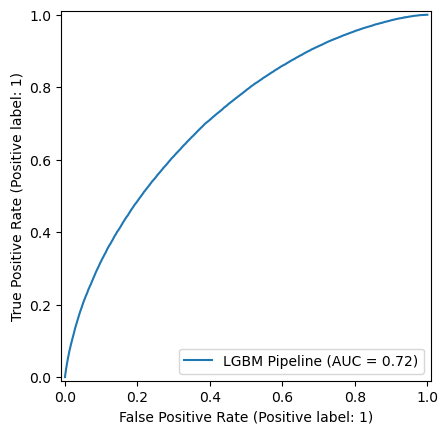

ROC AUC of lgbm model on 2016 data: 0.7177
Reminder : ROC AUC of unknown model on 2016 data : 0.7109


In [14]:
y_pred_lgbm_2016 = lgbm_pipeline_fitted_2016.predict(X_test)
y_proba_lgbm_2016 = lgbm_pipeline_fitted_2016.predict_proba(X_test)[:,1]
RocCurveDisplay.from_predictions(y_test, y_proba_lgbm_2016, name="LGBM Pipeline")
plt.show()

auc_lgbm_2016 = roc_auc_score(y_test, y_proba_lgbm_2016)

print(f"ROC AUC of lgbm model on 2016 data: {auc_lgbm_2016:.4f}")
print("Reminder : ROC AUC of unknown model on 2016 data : 0.7109")

Optimal treshold to maximize P&L : 0.78
P&L maximum: 533297774.96


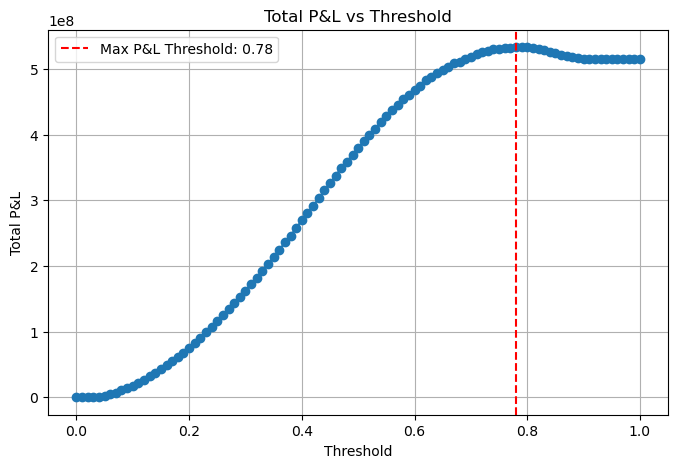

In [15]:
# Finding best treshold to maximize P&L
thresholds = np.linspace(0, 1, 101)
total_pnls = []

for threshold in thresholds:
    y_pred_lgbm_2016 = (y_proba_lgbm_2016 >= threshold).astype(int)
    
    
    pred_non_default = y_pred_lgbm_2016 == 0
    df_lend = og_df_val_1[pred_non_default]
    
    
    loan_years = df_lend['loan duration'].apply(lambda x: 3 if x == 0 else 5)
    int_rate_dec = df_lend['int_rate'] / 100
    
    
    loan_pnl = np.where(
        df_lend['target'] == 0,
        df_lend['funded_amnt'] * int_rate_dec * loan_years,  
        -df_lend['funded_amnt']  
    )
    
    total_pnls.append(loan_pnl.sum())


max_idx = np.argmax(total_pnls)
best_threshold = thresholds[max_idx]
max_pnl = total_pnls[max_idx]

print(f"Optimal treshold to maximize P&L : {best_threshold:.2f}")
print(f"P&L maximum: {max_pnl:.2f}")

plt.figure(figsize=(8,5))
plt.plot(thresholds, total_pnls, marker='o')
plt.axvline(best_threshold, color='red', linestyle='--', label=f"Max P&L Threshold: {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Total P&L")
plt.title("Total P&L vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
y_pred_lgbm_2016_adapted = (y_proba_lgbm_2016 >= 0.78).astype(int)

accuracy_lgbm_2016 = accuracy_score(y_test, y_pred_lgbm_2016_adapted)
print(f"Accuracy of the lgbm model with adapted treshold on 2016 data : {accuracy_lgbm_2016:.4f}")

# Compute P&L
pred_non_default = y_pred_lgbm_2016_adapted == 0
df_lend = og_df_val_1[pred_non_default]

loan_years = df_lend['loan duration'].apply(lambda x: 3 if x == 0 else 5)
int_rate_dec = df_lend['int_rate'] / 100

total_pnl_lgbm_2016 = np.where(
    df_lend['target'] == 0,
    df_lend['funded_amnt'] * int_rate_dec * loan_years,  # interest earned
    -df_lend['funded_amnt']  # principal lost
).sum()

print(f"Total P&L of lgbm model with adapted treshold on 2016 data: ${total_pnl_lgbm_2016:,.0f}")

Accuracy of the lgbm model with adapted treshold on 2016 data : 0.7961
Total P&L of lgbm model with adapted treshold on 2016 data: $533,297,775


Thus, we slightly improve the predictive power with this new model.

## Stability of lgbm model

In [17]:
# Training lgbm model on 2017-18 data for stability aalysis

X_train_20178 = og_df_train_stab.drop(columns=['target'])
y_train_20178 = og_df_train_stab['target']

X_test_201920 = og_df_test_stab.drop(columns=['target'])
y_test_201920 = og_df_test_stab['target']

lgbm_pipeline_fitted_201920 = joblib.load("lgbm_pipeline_ww.pkl").fit(X_train_20178,y_train_20178)
joblib.dump(lgbm_pipeline_fitted_201920, "lgbm_pipeline_fitted_201920.pkl")
joblib.dump(lgbm_pipeline_fitted_201920.named_steps["classifier"], "lgbm_model_only_fitted_201920.pkl")

/var/folders/l7/6_r15vlj5839j1442vhdwjh80000gn/T/ipykernel_39343/917579564.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emp_title_mean = X_full.groupby('emp_title')['target'].mean().reset_index()


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 63754, number of negative: 205060
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009042 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4990
[LightGBM] [Info] Number of data points in the train set: 268814, number of used features: 90
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


['lgbm_model_only_fitted_201920.pkl']

In [18]:
# Predicting for 201920 data
y_pred_lgbm_201920 = lgbm_pipeline_fitted_201920.predict(X_test_201920)
y_proba_lgbm_201920 = lgbm_pipeline_fitted_201920.predict_proba(X_test_201920)[:,1]

auc_lgbm_201920 = roc_auc_score(y_test_201920, y_proba_lgbm_201920)

print(f"ROC AUC of lgbm model on 201920 data: {auc_lgbm_201920:.4f}")

y_pred_lgbm_201920_adapted = (y_proba_lgbm_201920 >= 0.78).astype(int)

accuracy_lgbm_201920 = accuracy_score(y_test_201920, y_pred_lgbm_201920_adapted)
print(f"Accuracy of the lgbm model with adapted treshold on 201920 data : {accuracy_lgbm_201920:.4f}")

# Compute P&L
pred_non_default = y_pred_lgbm_201920_adapted == 0
df_lend = og_df_test_stab[pred_non_default]

loan_years = df_lend['loan duration'].apply(lambda x: 3 if x == 0 else 5)
int_rate_dec = df_lend['int_rate'] / 100

total_pnl_lgbm_201920 = np.where(
    df_lend['target'] == 0,
    df_lend['funded_amnt'] * int_rate_dec * loan_years,  # interest earned
    -df_lend['funded_amnt']  # principal lost
).sum()

print(f"Total P&L of lgbm model with adapted treshold on 201920 data: ${total_pnl_lgbm_201920:,.0f}")

ROC AUC of lgbm model on 201920 data: 0.7181
Accuracy of the lgbm model with adapted treshold on 201920 data : 0.8327
Total P&L of lgbm model with adapted treshold on 201920 data: $128,917,834


2012-2015 -> 2016 : AUC=0.7177, Accuracy=0.7961
2017-2018 -> 2019-2020 : AUC=0.7181, Accuracy=0.8327


/var/folders/l7/6_r15vlj5839j1442vhdwjh80000gn/T/ipykernel_39343/1511318919.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/l7/6_r15vlj5839j1442vhdwjh80000gn/T/ipykernel_39343/1511318919.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


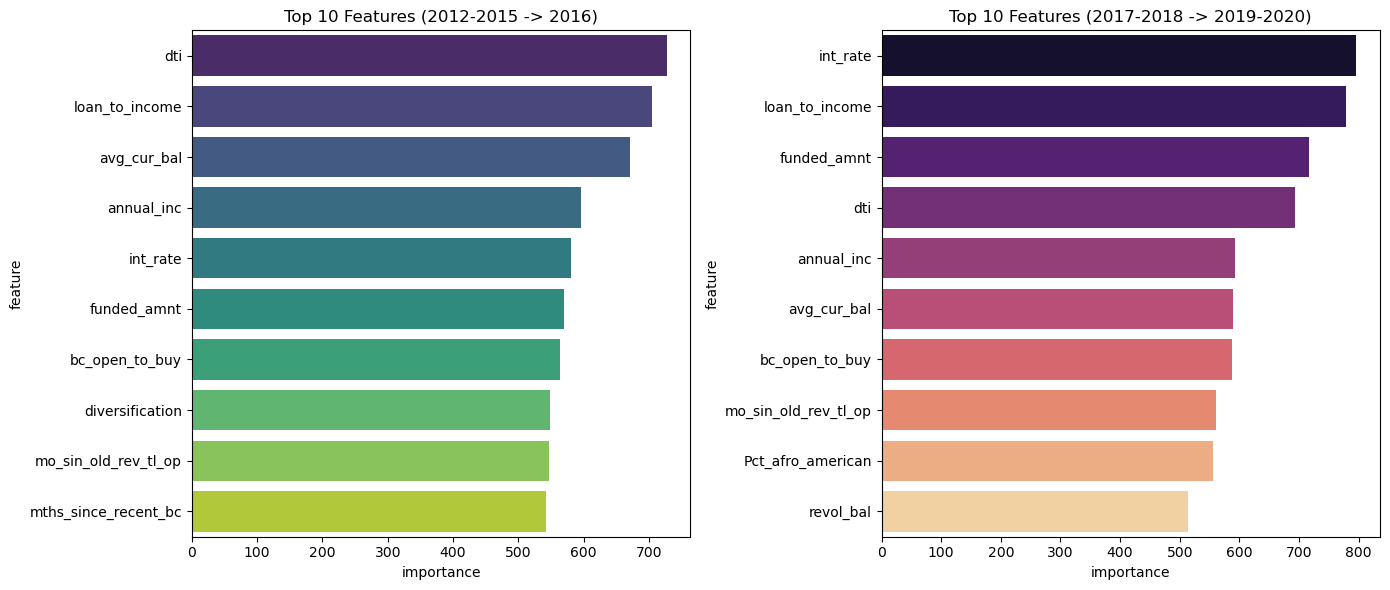

Pearson correlation between feature importances: 0.9657


In [19]:
lgbm_fitted_2016 = joblib.load("lgbm_model_only_fitted_2016.pkl")

feat_imp_lgbm_2016 = pd.DataFrame({
    "feature": lgbm_feature_names,
    "importance": lgbm_fitted_2016.feature_importances_
}).sort_values(by="importance", ascending=False)

lgbm_fitted_201920 = joblib.load("lgbm_model_only_fitted_201920.pkl")

feat_imp_lgbm_201920 = pd.DataFrame({
    "feature": lgbm_feature_names,
    "importance": lgbm_fitted_201920.feature_importances_
}).sort_values(by="importance", ascending=False)


print(f"2012-2015 -> 2016 : AUC={auc_lgbm_2016:.4f}, Accuracy={accuracy_lgbm_2016:.4f}")
print(f"2017-2018 -> 2019-2020 : AUC={auc_lgbm_201920:.4f}, Accuracy={accuracy_lgbm_201920:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.barplot(
    data=feat_imp_lgbm_2016.head(10),
    y="feature",
    x="importance",
    ax=axes[0],
    palette="viridis"
)
axes[0].set_title("Top 10 Features (2012-2015 -> 2016)")

sns.barplot(
    data=feat_imp_lgbm_201920.head(10),
    y="feature",
    x="importance",
    ax=axes[1],
    palette="magma"
)
axes[1].set_title("Top 10 Features (2017-2018 -> 2019-2020)")

plt.tight_layout()
plt.show()

# Compute stability/distance between feature importances

merged_imp = feat_imp_lgbm_2016.merge(feat_imp_lgbm_201920, on="feature", suffixes=("_2016","_201920"))

correlation = merged_imp["importance_2016"].corr(merged_imp["importance_201920"])

print(f"Pearson correlation between feature importances: {correlation:.4f}")

We can see that the model is really stable both in performance and feature importance.

# Step 4 : Global surrogate on lgbm model

## Linear regression

/var/folders/l7/6_r15vlj5839j1442vhdwjh80000gn/T/ipykernel_39343/917579564.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emp_title_mean = X_full.groupby('emp_title')['target'].mean().reset_index()


Linear Regression LGBM Surrogate R² on test set: 0.9076
Linear regression LGBM Surrogate MSE on test set: 0.003227


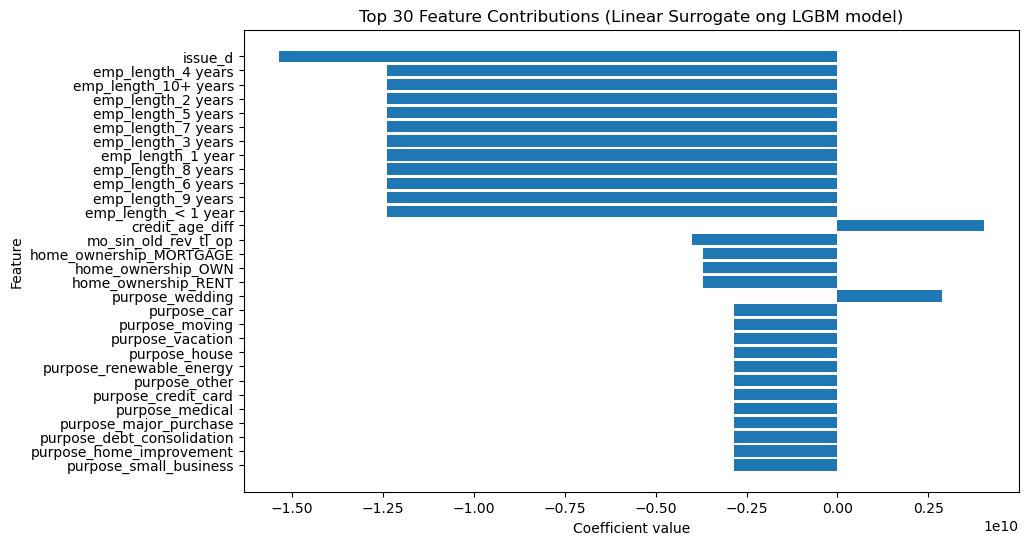

In [20]:

# Creating new df with predicted probabilities by lbgm model

X_1 = og_df_val_1.drop(columns=['target'], axis=1)
preprocessor = Preprocessor(n_clusters_title=10, n_clusters_zip=20).fit(feature_engineering(X_train),y_train)
X_11 = preprocessor.transform(feature_engineering(X_1))
lgbm_prob = pd.Series(y_proba_lgbm_2016, name="Predicted probabilities",index=X_11.index)
withLgbmDP_df = pd.concat([X_11, lgbm_prob], axis=1)

X = withLgbmDP_df.drop(columns=['Predicted probabilities'],axis=1)
y = withLgbmDP_df['Predicted probabilities']

# Preparing training and test sets
X_train_lgbm_surrogate, X_test_lgbm_surrogate, y_train_lgbm_surrogate, y_test_lgbm_surrogate = train_test_split(
    withLgbmDP_df.drop(columns=['Predicted probabilities'],axis=1),
    withLgbmDP_df['Predicted probabilities'], 
    test_size=0.2,       
    random_state=42,    
    shuffle=True      
)


# training model
surrogate_linear_lgbm_model = LinearRegression()
surrogate_linear_lgbm_model.fit(X_train_lgbm_surrogate, y_train_lgbm_surrogate)

# Predicting and computing surrogate model proximity to unknown model 
y_pred_surrogate_lgbm_model_2016 = surrogate_linear_lgbm_model.predict(X_test_lgbm_surrogate)
r2 = r2_score(y_test_lgbm_surrogate, y_pred_surrogate_lgbm_model_2016)
mse = mean_squared_error(y_test_lgbm_surrogate, y_pred_surrogate_lgbm_model_2016)
print(f"Linear Regression LGBM Surrogate R² on test set: {r2:.4f}")
print(f"Linear regression LGBM Surrogate MSE on test set: {mse:.6f}")

# Plotting feature contributions through coefficients

feature_names = withLgbmDP_df.drop(columns=['Predicted probabilities'],axis=1).columns

coefficients = surrogate_linear_lgbm_model.coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coef': np.abs(coefficients)
}).sort_values(by='abs_coef', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(coef_df['feature'][:30][::-1], coef_df['coefficient'][:30][::-1])
plt.xlabel('Coefficient value')
plt.ylabel('Feature')
plt.title('Top 30 Feature Contributions (Linear Surrogate ong LGBM model)')
plt.show()

## Decision tree regressor

Decision Tree Surrogate R² on test set: 0.7305
Decision Tree Surrogate MSE on test set: 0.009409


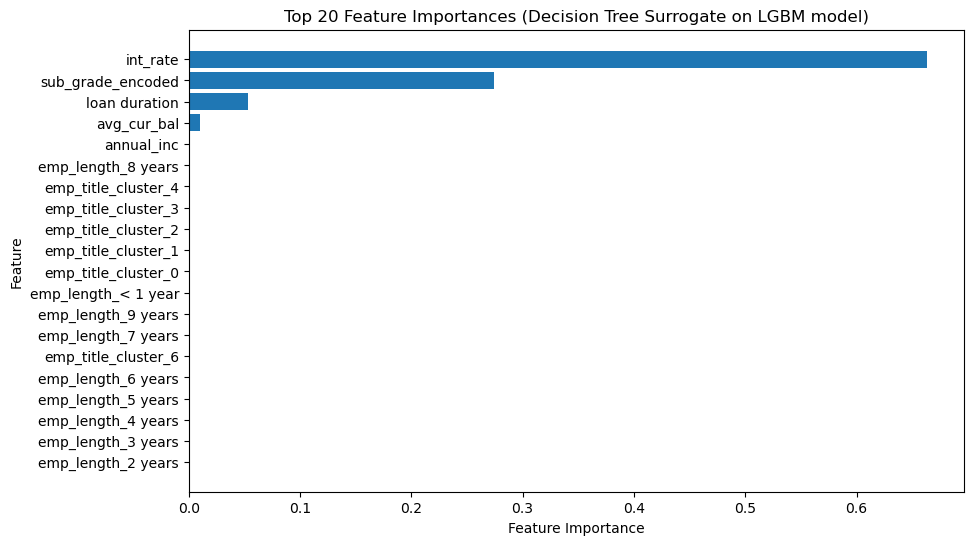

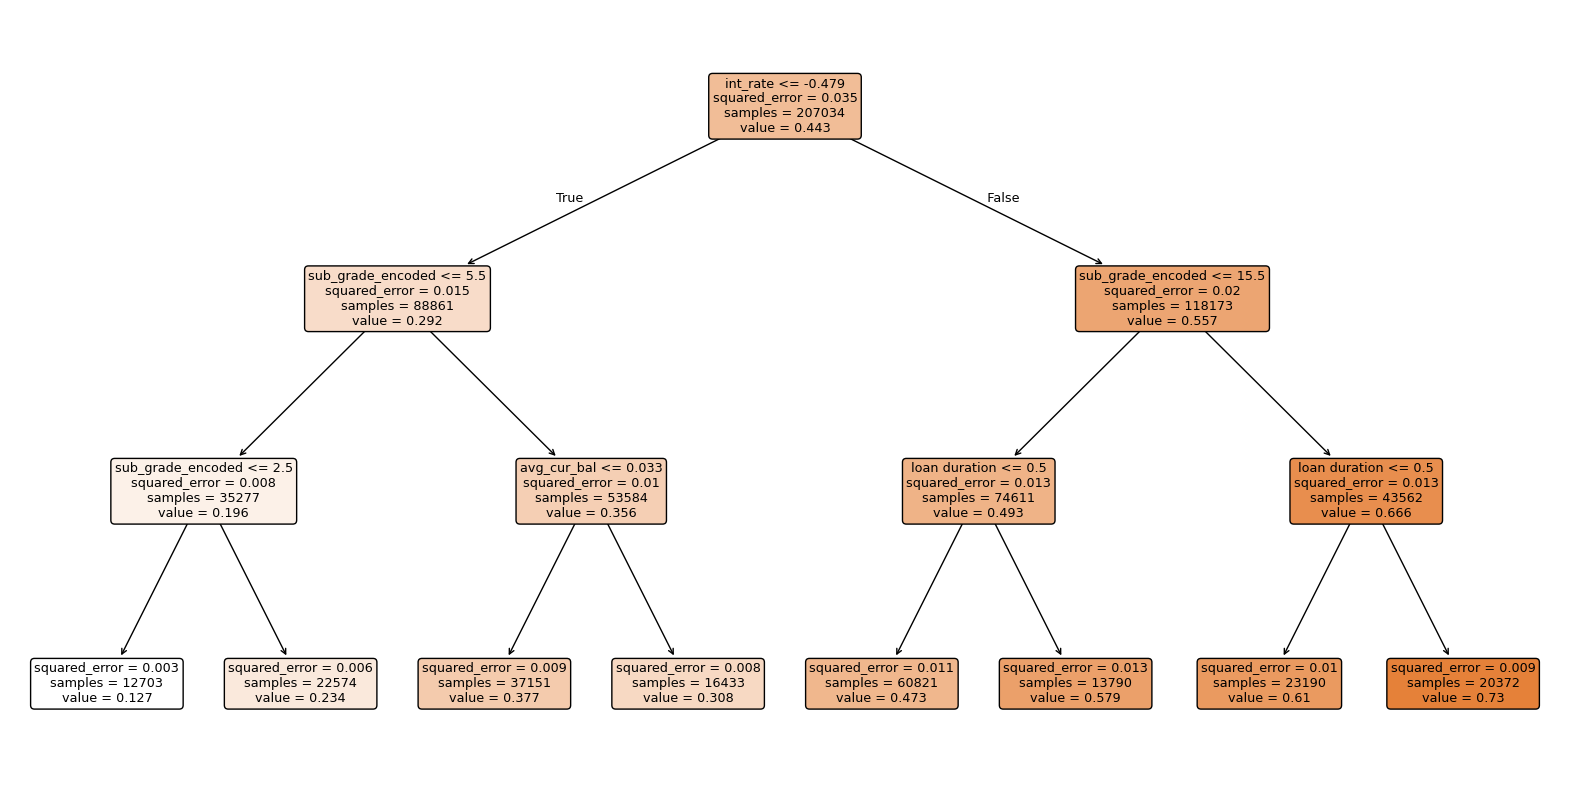

In [21]:

# training model
surrogate_tree_lgbm_model = DecisionTreeRegressor(max_depth=3, random_state=8)
surrogate_tree_lgbm_model.fit(X_train_lgbm_surrogate, y_train_lgbm_surrogate)

# Predicting and computing surrogate model proximity to unknown model 
y_pred_tree_surrogate_lgbm_model_2016 = surrogate_tree_lgbm_model.predict(X_test_lgbm_surrogate) 
r2_tree = r2_score(y_test_lgbm_surrogate, y_pred_tree_surrogate_lgbm_model_2016)
mse_tree = mean_squared_error(y_test_lgbm_surrogate, y_pred_tree_surrogate_lgbm_model_2016)
print(f"Decision Tree Surrogate R² on test set: {r2_tree:.4f}")
print(f"Decision Tree Surrogate MSE on test set: {mse_tree:.6f}")

# Plotting feature importances

importances = surrogate_tree_lgbm_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'][:20][::-1], importance_df['importance'][:20][::-1])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances (Decision Tree Surrogate on LGBM model)')
plt.show()

plt.figure(figsize=(20,10))
plot_tree(surrogate_tree_lgbm_model, feature_names=feature_names, filled=True, rounded=True, max_depth=3)
plt.show()

According to these results, if we compare the surogate decision trees of the unknown model (step 1) and one of the lgbm model, we see that they are very similar with mostly the same features at the top of importance plot (int_rate, loan duration and sub_grade for lgbm surogate model vs grade for unknown model's surogate). This indicates that the unknown model and our model rely on the same underlying logic to make predictions, this is not that surprising as their performance results are also really close. 

# Step 5 : Global interpretability with PDP method

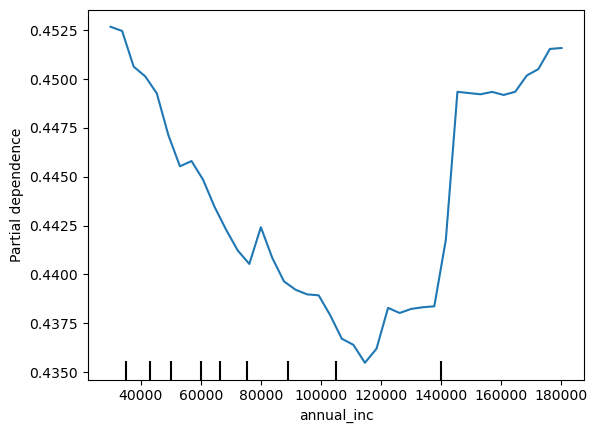

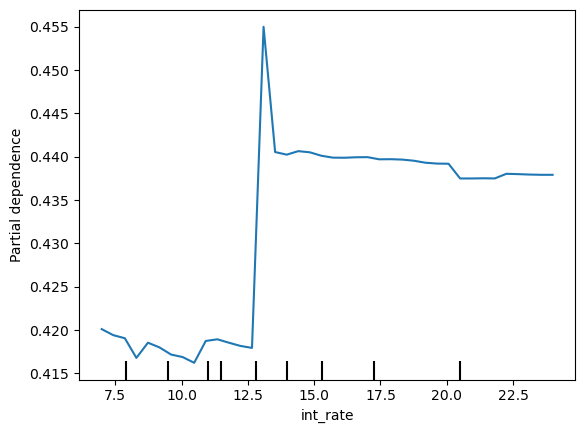

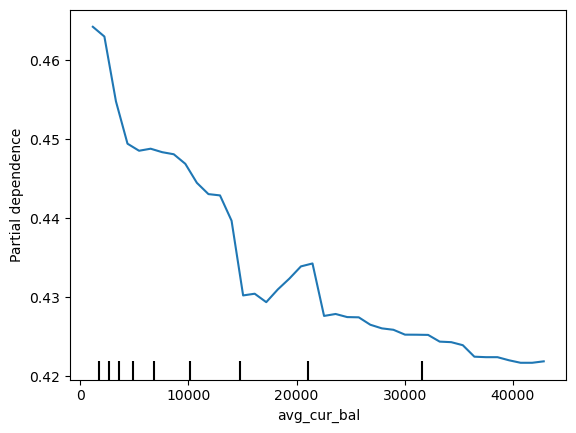

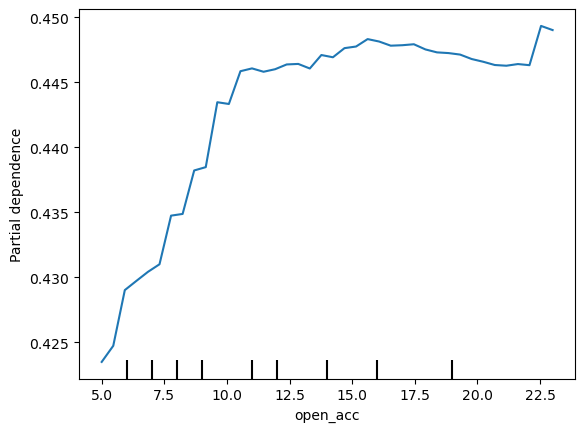

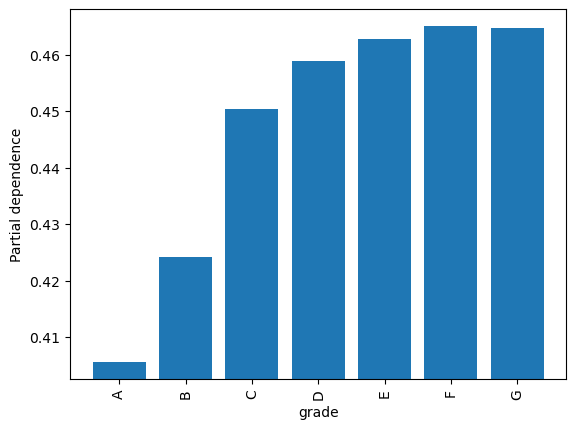

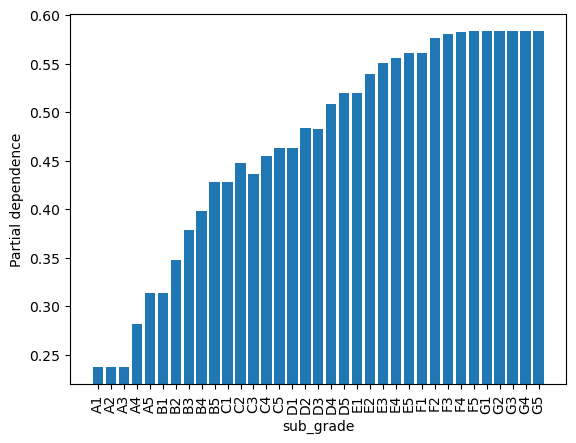

In [22]:
numerical_features_to_plot = ['annual_inc','int_rate','avg_cur_bal','open_acc']
categorical_feature_to_plot = ['grade', 'sub_grade']

for feature in numerical_features_to_plot : 
    PartialDependenceDisplay.from_estimator(
        lgbm_pipeline_fitted_2016,
        X_test,
        features=[feature],
        kind='average',
        grid_resolution=40)
    plt.show()

for feature in categorical_feature_to_plot :
    PartialDependenceDisplay.from_estimator(
        lgbm_pipeline_fitted_2016,
        X_test,
        features=[feature],
        kind='average',
        grid_resolution=40,
        categorical_features=[feature])
    plt.show()

Here, we decided to display some of demonstrative PDP plots. We recall that PDP plots show the average effect of one feature on the predicted outcome of the model, while marginalizing over the other features. Some of the results we got there are consistent with the understandings gained through the surogate models :
- grade and sub_grade are useful features (i.e. they help the model to discriminate) as the plots are showing a significant effect on the average predicted outcome : the lower the grade the higher the average predicted risk. 

Partial dependance plot is a very interesting technique as it even helps us to gain a better understanding of the effect of each specific feature on the average predicted outcome. Taking the example open_acc feature PDP we can see this feature has a great influence from 5 to approximately 11 units. After 11 units, the feature discriminatory power diminishes significantly. 

Taking the example of int_rate, which was highlighted as a very important feature by surrogate decision tree, we can get a better understanding of the discriminatory strength of this feature by looking at its PDP : we can see that it is almost a step function indicating that this feature mainly allows to discriminate between to groups of instances (the ones with int_rate < 12.5 and the others).

**To conclude PDP allows us to confirm the intuitions given by the surrogate models but above all allows us to gain a more precise analysis on features respective effects**

# Step 6 : Local interpretability : LIME method

### **Approach** 

*LIME and SHAP were used for the local interpretion of the model. ICE could have been added as complementary to the observations of LIME, but the outcome of the LIME analysis was judged to be demonstrative enough.*

We tried to establish a link between the results obtained from the global interpretability analysis to have a smooth explanation.

From the PDP plots, we observed interesting patterns for annual incomes above 120k, interest rates of 8, 14, 16, and 20, and for subgrade values such as A2, B4, C5, and E5. 
  Based on these insights, we decided to conduct local interpretability analyses on data points with values approximately close to those identified.

We examined local points that were correctly classified as defaulted (**TRUE POSITIVE**) and wrongly misclassified as defaulted (**FALSE NEGATIVE**), in order to compare whether the feature importance differed between the two cases.

### Data points to focus on for analysis with LIME and SHAP 

In [23]:
print("Finding Specific Data Points for LIME Analysis")

def find_lime_analysis_candidates():
    """
    Find specific data points for targeted LIME analysis following project methodology
    Criteria: annual_inc > 130k, int_rate in [8, 14, 16, 20], sub_grade in ['A2', 'B4', 'C5', 'E5']
    """
    
    # Use 2016 validation data (og_df_val_1)
    search_df = og_df_val_1.copy()
    
    # Define search criteria
    criteria = {
        'annual_inc_threshold': 130000,
        'target_int_rates': [8.0, 14.0, 16.0, 20.0],
        'target_subgrades': ['A2', 'B4', 'C5', 'E5']
    }
    
   
    
    lime_candidates = {
        'high_income': [],
        'specific_rates': [],
        'specific_subgrades': [],
        'combined_criteria': []
    }
    
    
    high_income_mask = search_df['annual_inc'] > criteria['annual_inc_threshold']
    high_income_indices = search_df[high_income_mask].index.tolist()
    lime_candidates['high_income'] = high_income_indices[:5]  
    
    print(f"\n High Income Candidates (annual_inc > ${criteria['annual_inc_threshold']:,}):")
    print(f"   Found {len(high_income_indices)} instances")
    
    if len(high_income_indices) > 0:
        high_income_sample = search_df.loc[high_income_indices[:5]]
        print(f"   Sample instances (showing first 5):")
        for idx, (orig_idx, row) in enumerate(high_income_sample.iterrows()):
            relative_idx = search_df.index.get_loc(orig_idx)  
            print(f"      Instance {relative_idx}: income=${row['annual_inc']:,.0f}, "
                  f"rate={row['int_rate']:.2f}%, grade={row['sub_grade']}, "
                  f"target={'Bad' if row['target'] == 1 else 'Good'}")
    
    
    rate_candidates = []
    for rate in criteria['target_int_rates']:
        
        rate_mask = (search_df['int_rate'] >= rate - 0.1) & (search_df['int_rate'] <= rate + 0.1)
        rate_indices = search_df[rate_mask].index.tolist()
        rate_candidates.extend(rate_indices[:2])  
    
    lime_candidates['specific_rates'] = rate_candidates
    
    print(f"\n Specific Interest Rate Candidates:")
    for rate in criteria['target_int_rates']:
        rate_mask = (search_df['int_rate'] >= rate - 0.1) & (search_df['int_rate'] <= rate + 0.1)
        count = rate_mask.sum()
        print(f"   Rate ~{rate}%: {count} instances found")
        
        if count > 0:
            rate_sample = search_df[rate_mask].head(2)
            for orig_idx, row in rate_sample.iterrows():
                relative_idx = search_df.index.get_loc(orig_idx)
                print(f"      Instance {relative_idx}: income=${row['annual_inc']:,.0f}, "
                      f"rate={row['int_rate']:.2f}%, grade={row['sub_grade']}")
    
    
    subgrade_candidates = []
    for subgrade in criteria['target_subgrades']:
        subgrade_mask = search_df['sub_grade'] == subgrade
        subgrade_indices = search_df[subgrade_mask].index.tolist()
        subgrade_candidates.extend(subgrade_indices[:2])  
    
    lime_candidates['specific_subgrades'] = subgrade_candidates
    
    print(f"\nSpecific Sub-grade Candidates:")
    for subgrade in criteria['target_subgrades']:
        subgrade_mask = search_df['sub_grade'] == subgrade
        count = subgrade_mask.sum()
        print(f"   Sub-grade {subgrade}: {count} instances found")
        
        if count > 0:
            subgrade_sample = search_df[subgrade_mask].head(2)
            for orig_idx, row in subgrade_sample.iterrows():
                relative_idx = search_df.index.get_loc(orig_idx)
                print(f"      Instance {relative_idx}: income=${row['annual_inc']:,.0f}, "
                      f"rate={row['int_rate']:.2f}%, grade={row['sub_grade']}")
    
    
    print(f"\nCombined Criteria Analysis:")
    
    # High income + specific rates
    high_income_specific_rates = []
    for rate in criteria['target_int_rates']:
        combined_mask = (
            (search_df['annual_inc'] > criteria['annual_inc_threshold']) &
            (search_df['int_rate'] >= rate - 0.1) & 
            (search_df['int_rate'] <= rate + 0.1)
        )
        combined_indices = search_df[combined_mask].index.tolist()
        high_income_specific_rates.extend(combined_indices)
    
    print(f"   High income + specific rates: {len(high_income_specific_rates)} instances")
    
    # High income + specific subgrades
    high_income_specific_subgrades = []
    for subgrade in criteria['target_subgrades']:
        combined_mask = (
            (search_df['annual_inc'] > criteria['annual_inc_threshold']) &
            (search_df['sub_grade'] == subgrade)
        )
        combined_indices = search_df[combined_mask].index.tolist()
        high_income_specific_subgrades.extend(combined_indices)
    
    print(f"   High income + specific subgrades: {len(high_income_specific_subgrades)} instances")
    
    # All three criteria
    triple_criteria = []
    for rate in criteria['target_int_rates']:
        for subgrade in criteria['target_subgrades']:
            combined_mask = (
                (search_df['annual_inc'] > criteria['annual_inc_threshold']) &
                (search_df['int_rate'] >= rate - 0.1) & 
                (search_df['int_rate'] <= rate + 0.1) &
                (search_df['sub_grade'] == subgrade)
            )
            combined_indices = search_df[combined_mask].index.tolist()
            triple_criteria.extend(combined_indices)
    
    print(f"   All three criteria: {len(triple_criteria)} instances")
    
    # Compile final candidate 
    priority_candidates = []
    
    
    if triple_criteria:
        priority_candidates.extend(triple_criteria[:3])
    
    
    remaining_high_rate = [idx for idx in high_income_specific_rates if idx not in priority_candidates]
    priority_candidates.extend(remaining_high_rate[:3])
    
      
    remaining_high_subgrade = [idx for idx in high_income_specific_subgrades if idx not in priority_candidates]
    priority_candidates.extend(remaining_high_subgrade[:3])
    
    
    remaining_high_income = [idx for idx in high_income_indices if idx not in priority_candidates]
    priority_candidates.extend(remaining_high_income[:5])
    
    lime_candidates['combined_criteria'] = priority_candidates
    
    
    relative_candidates = {}
    for category, indices in lime_candidates.items():
        relative_indices = []
        for abs_idx in indices:
            try:
                relative_idx = search_df.index.get_loc(abs_idx)
                relative_indices.append(relative_idx)
            except KeyError:
                continue
        relative_candidates[category] = relative_indices
    
    return relative_candidates, search_df, criteria

# Execute the search
print("Executing candidate search...")
lime_candidates, validation_df, search_criteria = find_lime_analysis_candidates()

# Display final recommendations
print(f"\nRECOMMENDED LIME ANALYSIS CANDIDATES:")
print(f"="*50)

print(f"\nPriority Candidates (Combined Criteria): {len(lime_candidates['combined_criteria'])} instances")
for i, idx in enumerate(lime_candidates['combined_criteria'][:5]):
    row = validation_df.iloc[idx]
    print(f"   #{i+1} Instance {idx}: income=${row['annual_inc']:,.0f}, "
          f"rate={row['int_rate']:.2f}%, grade={row['sub_grade']}, "
          f"target={'Bad Credit' if row['target'] == 1 else 'Good Credit'}")

print(f"\n High Income Candidates: {len(lime_candidates['high_income'])} instances")
for i, idx in enumerate(lime_candidates['high_income'][:3]):
    row = validation_df.iloc[idx]
    print(f"   #{i+1} Instance {idx}: income=${row['annual_inc']:,.0f}, "
          f"rate={row['int_rate']:.2f}%, grade={row['sub_grade']}")

print(f"\n Specific Rate Candidates: {len(lime_candidates['specific_rates'])} instances")
for i, idx in enumerate(lime_candidates['specific_rates'][:3]):
    row = validation_df.iloc[idx]
    print(f"   #{i+1} Instance {idx}: income=${row['annual_inc']:,.0f}, "
          f"rate={row['int_rate']:.2f}%, grade={row['sub_grade']}")

print(f"\n Specific Sub-grade Candidates: {len(lime_candidates['specific_subgrades'])} instances")
for i, idx in enumerate(lime_candidates['specific_subgrades'][:3]):
    row = validation_df.iloc[idx]
    print(f"   #{i+1} Instance {idx}: income=${row['annual_inc']:,.0f}, "
          f"rate={row['int_rate']:.2f}%, grade={row['sub_grade']}")

# Store candidates for easy access in LIME analysis
recommended_indices = lime_candidates['combined_criteria'][:5] if lime_candidates['combined_criteria'] else lime_candidates['high_income'][:5]

print(f"   Use these instance indices: {recommended_indices}")


lime_analysis_candidates = {
    'recommended_indices': recommended_indices,
    'all_candidates': lime_candidates,
    'search_criteria': search_criteria,
    'validation_data': validation_df
}



Finding Specific Data Points for LIME Analysis
Executing candidate search...

 High Income Candidates (annual_inc > $130,000):
   Found 28730 instances
   Sample instances (showing first 5):
      Instance 2: income=$156,000, rate=6.97%, grade=A3, target=Good
      Instance 7: income=$240,000, rate=5.32%, grade=A1, target=Good
      Instance 10: income=$137,000, rate=11.47%, grade=B5, target=Good
      Instance 16: income=$150,000, rate=12.99%, grade=C2, target=Good
      Instance 30: income=$210,000, rate=7.89%, grade=A5, target=Good

 Specific Interest Rate Candidates:
   Rate ~8.0%: 3884 instances found
      Instance 54910: income=$28,000, rate=7.91%, grade=A5
      Instance 55216: income=$60,000, rate=7.91%, grade=A5
   Rate ~14.0%: 9538 instances found
      Instance 54687: income=$70,000, rate=13.99%, grade=C4
      Instance 55237: income=$45,000, rate=13.99%, grade=C4
   Rate ~16.0%: 3124 instances found
      Instance 198863: income=$78,000, rate=15.99%, grade=C5
      Instanc

### More Data Points for LIME and SHAP analysis: 5 True Positive cases and 5 False Negative Cases

In [24]:
def find_tp_fn_cases(self=og_df_val_1['target']):
    """
    Find True Positive and False Negative case indices
    """
    print("STEP 6: Finding TP/FN Cases for LIME Analysis")
    print("="*50)
    
    # Use existing predictions from previous analysis (following project pattern)
    y_pred = y_pred_lgbm_2016_adapted  # Already computed with optimal threshold
    
    # Find True Positive cases (actual=1, predicted=1)
    tp_mask = (og_df_val_1['target'] == 1) & (y_pred_lgbm_2016_adapted == 1)
    tp_indices = og_df_val_1['target'][tp_mask].index[:3]
    
    # Find False Negative cases (actual=1, predicted=0)  
    fn_mask = (og_df_val_1['target'] == 1) & (y_pred_lgbm_2016_adapted == 0)
    fn_indices = og_df_val_1['target'][fn_mask].index[:3]

    # Convert to relative positions in test set
    X_test_raw__ = og_df_val_1.drop(columns=['target'])
    tp_relative = [X_test_raw__.index.get_loc(idx) for idx in tp_indices]
    fn_relative = [X_test_raw__.index.get_loc(idx) for idx in fn_indices]

    print(f"True Positive cases: {tp_relative}")
    print(f"False Negative cases: {fn_relative}")
    
    return tp_relative + fn_relative

# Add to analyzer and get the indices
find_tp_fn_cases() 

STEP 6: Finding TP/FN Cases for LIME Analysis
True Positive cases: [48, 143, 225]
False Negative cases: [4, 8, 11]


[48, 143, 225, 4, 8, 11]

### Set up functions for LIME and SHAP

In [25]:
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

class CreditInterpretabilityAnalysis:
    def __init__(self):
        """
        Initialize interpretability analysis
        Uses existing LGBM pipeline and temporal data splits from Steps 2-3
        """
        print("Initializing interpretability analysis...")
        
        # Use existing LGBM pipeline and temporal data splits
        self.model = lgbm_pipeline_fitted_2016
        self.X_train_raw = og_df_train_1.drop(columns=['target'])
        self.X_test_raw = og_df_val_1.drop(columns=['target']) 
        self.y_train = og_df_train_1['target']
        self.y_test = og_df_val_1['target']
        
        # Preprocess data through the same pipeline as the trained model
        self._setup_preprocessed_data()
        
        print(f"Model loaded: {type(self.model.named_steps['classifier']).__name__}")
        print(f" Training data: {self.X_train_raw.shape[0]} samples, {len(self.feature_names)} features")
        print(f" Test data: {self.X_test_raw.shape[0]} samples")
        print(f" Using temporal split: 2012-2015 → 2016")
        
    def _setup_preprocessed_data(self):
        """
        Apply the same preprocessing pipeline as the trained model
        Ensures consistency with Step 2 model architecture and preprocessing
        """
        # Apply feature engineering step
        X_train_engineered = self.model.named_steps['feature engineering'].transform(self.X_train_raw)
        X_test_engineered = self.model.named_steps['feature engineering'].transform(self.X_test_raw)
        
        # Apply preprocessing step
        self.X_train_processed = self.model.named_steps['preprocessor'].transform(X_train_engineered)
        self.X_test_processed = self.model.named_steps['preprocessor'].transform(X_test_engineered)
        
        # Extract feature names from preprocessed data
        self.feature_names = self.X_train_processed.columns.tolist()
        
        # Store preprocessor for consistent transformations
        self.preprocessor = self.model.named_steps['preprocessor']
        self.feature_engineer = self.model.named_steps['feature engineering']
        
    def implement_lime_analysis(self, instance_idx, num_features=10):
        """
        Step 6: LIME Analysis 
        """
             
        # instance_idx refers to great example indices from recommended candidates in previous code block
        all_results = {}
        
        indices = np.atleast_1d(instance_idx).tolist()

        for index in indices:
            try:
                # Create LIME explainer using preprocessed training data
                explainer = lime.lime_tabular.LimeTabularExplainer(
                    self.X_train_processed.values,
                    feature_names=self.feature_names,
                    class_names=['Good Credit', 'Bad Credit'],
                    mode='classification',
                    discretize_continuous=True,
                    random_state=42
                )
                
                # Select preprocessed instance to explain
                instance_processed = self.X_test_processed.iloc[index].values
                
                
                def model_predict_proba(X_preprocessed):
                    """Prediction wrapper for LIME - expects preprocessed data"""
                    return self.model.named_steps['classifier'].predict_proba(X_preprocessed)
                
                # Generate LIME explanation
                explanation = explainer.explain_instance(
                    instance_processed,
                    model_predict_proba,
                    num_features=num_features
                )
                
                # Get prediction details
                instance_raw = self.X_test_raw.iloc[index:index+1]
                actual_class = 'Bad Credit' if self.y_test.iloc[index] == 1 else 'Good Credit'
                pred_class = 'Bad Credit' if self.model.predict(instance_raw)[0] == 1 else 'Good Credit'
                pred_proba = self.model.predict_proba(instance_raw)[0]
                
                
                print(f"\n LIME Explanation for test instance {index}:")
                print(f"    Actual class: {actual_class}")
                print(f"    Predicted class: {pred_class}")
                print(f"   Prediction probability: [Good: {pred_proba[0]:.4f}, Bad: {pred_proba[1]:.4f}]")
                
                # Extract and display feature importance
                lime_features = explanation.as_list()
                print(f"\n Top {num_features} features according to LIME:")
                for feature, importance in lime_features:
                    direction = "↗️" if importance > 0 else "↘️"
                    print(f"   {direction} {feature}: {importance:+.4f}")
                
                # Generate visualization 
                fig = explanation.as_pyplot_figure()
                fig.suptitle(f'LIME Local Interpretation - Instance {index} ({actual_class})', 
                            fontsize=14, weight='bold')
                plt.tight_layout()
                plt.show()

                # Store results for this instance
                all_results[index] = (explanation, lime_features)
                
                print(f"Successfully processed instance {index}")
                
            except Exception as e:
                print(f"Error in LIME analysis: {str(e)}")
                print(f"   Debugging info: X_train_processed shape: {self.X_train_processed.shape}")
                print(f"   Feature names count: {len(self.feature_names)}")
                continue
        

        # Return all results after processing all instances
        if all_results:
            print(f"\n Successfully processed {len(all_results)} instances")
            print(f"   Processed instances: {list(all_results.keys())}")
            return all_results  # Return dictionary with all results
        else:
            print(" No instances were successfully processed")
            return None
        
    def implement_shap_analysis(self, instance_idx, max_display=15):
        """
        Step 7: SHAP Analysis - Local Interpretability (Multiple instances supported)
        """
        print("STEP 7: SHAP Analysis")
        print("="*30)
        
        indices = np.atleast_1d(instance_idx).tolist()
        all_results = {}
        
        try:
            # Create explainer and compute SHAP values
            explainer = shap.TreeExplainer(self.model.named_steps['classifier'])
            max_idx = int(max(indices)) + 50  # Ensure it's a single integer
            max_idx = min(max_idx, len(self.X_test_processed))  # Don't exceed dataset size
            shap_values = explainer.shap_values(self.X_test_processed.iloc[:max_idx])
            
            # Handle binary classification
            if isinstance(shap_values, list):
                shap_values_positive = shap_values[1]
                expected_value = explainer.expected_value[1]
            else:
                shap_values_positive = shap_values
                expected_value = explainer.expected_value
            
            # Process each instance
            for idx in indices:
                if idx >= len(shap_values_positive):
                    print(f"Skipping instance {idx} - out of range")
                    continue
                    
                # Get instance data
                instance_raw = self.X_test_raw.iloc[idx:idx+1]
                shap_vals_instance = shap_values_positive[idx]
                
                # Get predictions
                actual = 'Bad Credit' if self.y_test.iloc[idx] == 1 else 'Good Credit'
                predicted = 'Bad Credit' if self.model.predict(instance_raw)[0] == 1 else 'Good Credit'
                prob = self.model.predict_proba(instance_raw)[0]
                
                print(f"\nInstance {idx}: {actual} | Predicted: {predicted} | Prob: {prob[1]:.3f}")
                
                # Feature importance
                feature_importance = list(zip(self.feature_names, shap_vals_instance))
                feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)
                
                print(f"Top {min(5, max_display)} SHAP features:")
                for feature, importance in feature_importance[:min(5, max_display)]:
                    print(f"  {feature}: {importance:+.4f}")
                
                # Waterfall plot
                try:
                    shap.waterfall_plot(
                        shap.Explanation(
                            values=shap_vals_instance,
                            base_values=expected_value,
                            data=self.X_test_processed.iloc[idx].values,
                            feature_names=self.feature_names
                        ),
                        max_display=max_display,
                        show=True
                    )
                except:
                    print(f"  (Waterfall plot failed for instance {idx})")
                
                all_results[idx] = (shap_vals_instance, feature_importance)
            
            return all_results if all_results else None
            
        except Exception as e:
            print(f"Error in SHAP analysis: {str(e)}")
            return None

    def compare_interpretability_methods(self, instance_idx=0, top_k=10):
        """
        Comprehensive comparison of LIME vs SHAP explanations
        """
        print("INTERPRETABILITY COMPARISON: LIME vs SHAP")
        print("="*60)
        
        try:
            # Run both analyses
            print(" Running LIME analysis...")
            lime_explanation, lime_features = self.implement_lime_analysis(instance_idx, top_k)
            
            print("\n Running SHAP analysis...")
            shap_values, shap_features = self.implement_shap_analysis(instance_idx, top_k)
            
            if lime_features and shap_features:
                # Create detailed comparison
                self._create_detailed_comparison(lime_features, shap_features, instance_idx, top_k)
                
                return {
                    'lime_features': lime_features,
                    'shap_features': shap_features,
                    'instance_idx': instance_idx
                }
            else:
                print(" Unable to complete comparison due to analysis errors")
                return None
                
        except Exception as e:
            print(f" Error in interpretability comparison: {str(e)}")
            return None
    


### Run LIME with 2 different approaches

 Initializing Credit Interpretability Analysis
Initializing interpretability analysis...
Model loaded: LGBMClassifier
 Training data: 524431 samples, 92 features
 Test data: 258793 samples
 Using temporal split: 2012-2015 → 2016

 Running LIME Analysis...

 LIME Explanation for test instance 16:
    Actual class: Good Credit
    Predicted class: Good Credit
   Prediction probability: [Good: 0.6553, Bad: 0.3447]

 Top 10 features according to LIME:
   ↘️ zip_cluster_3 <= 0.00: -0.1595
   ↗️ zip_cluster_8 <= 0.00: +0.1308
   ↗️ emp_title_cluster_8 <= 0.00: +0.0977
   ↗️ zip_cluster_11 <= 0.00: +0.0955
   ↗️ zip_cluster_15 <= 0.00: +0.0935
   ↘️ loan duration <= 0.00: -0.0911
   ↗️ zip_cluster_4 <= 0.00: +0.0857
   ↘️ purpose_renewable_energy <= 0.00: -0.0782
   ↗️ zip_cluster_7 <= 0.00: +0.0756
   ↘️ emp_title_cluster_2 <= 0.00: -0.0646


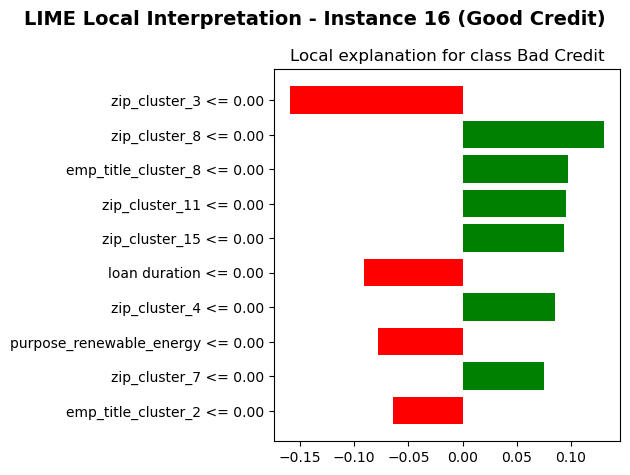

Successfully processed instance 16

 LIME Explanation for test instance 323:
    Actual class: Good Credit
    Predicted class: Bad Credit
   Prediction probability: [Good: 0.3110, Bad: 0.6890]

 Top 10 features according to LIME:
   ↘️ zip_cluster_3 <= 0.00: -0.1483
   ↗️ sub_grade_encoded > 16.00: +0.1374
   ↗️ zip_cluster_8 <= 0.00: +0.1279
   ↗️ emp_title_cluster_8 <= 0.00: +0.0997
   ↗️ zip_cluster_11 <= 0.00: +0.0909
   ↗️ 0.00 < loan duration <= 1.00: +0.0907
   ↗️ zip_cluster_4 <= 0.00: +0.0895
   ↗️ zip_cluster_7 <= 0.00: +0.0885
   ↗️ zip_cluster_15 <= 0.00: +0.0818
   ↗️ purpose_wedding <= 0.00: +0.0546


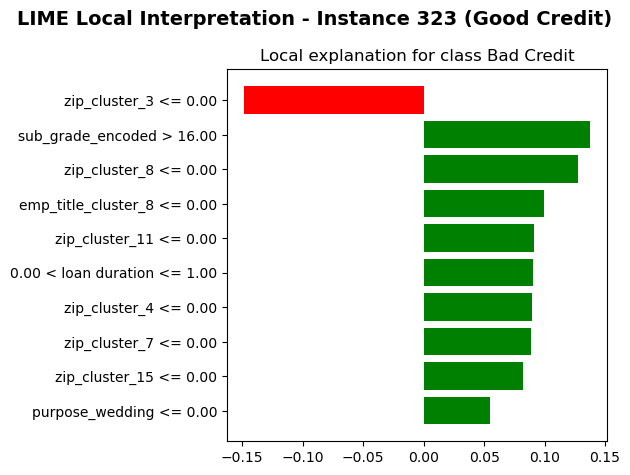

Successfully processed instance 323

 LIME Explanation for test instance 198863:
    Actual class: Good Credit
    Predicted class: Good Credit
   Prediction probability: [Good: 0.5873, Bad: 0.4127]

 Top 10 features according to LIME:
   ↘️ zip_cluster_3 <= 0.00: -0.1971
   ↗️ zip_cluster_8 <= 0.00: +0.1298
   ↗️ emp_title_cluster_8 <= 0.00: +0.0996
   ↗️ zip_cluster_11 <= 0.00: +0.0983
   ↗️ zip_cluster_15 <= 0.00: +0.0957
   ↘️ loan duration <= 0.00: -0.0908
   ↗️ zip_cluster_4 <= 0.00: +0.0863
   ↘️ purpose_renewable_energy <= 0.00: -0.0784
   ↗️ zip_cluster_7 <= 0.00: +0.0764
   ↘️ issue_d > 0.84: -0.0100


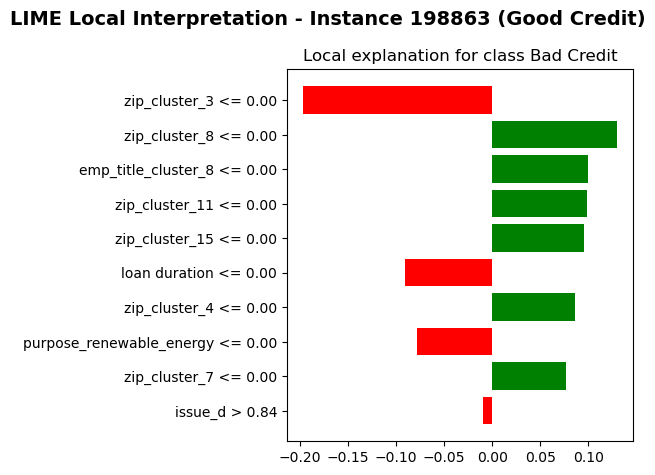

Successfully processed instance 198863

 LIME Explanation for test instance 141:
    Actual class: Bad Credit
    Predicted class: Bad Credit
   Prediction probability: [Good: 0.2486, Bad: 0.7514]

 Top 10 features according to LIME:
   ↗️ sub_grade_encoded > 16.00: +0.1381
   ↘️ zip_cluster_3 <= 0.00: -0.1342
   ↗️ zip_cluster_11 <= 0.00: +0.1177
   ↗️ zip_cluster_8 <= 0.00: +0.1165
   ↗️ emp_title_cluster_8 <= 0.00: +0.1106
   ↗️ zip_cluster_15 <= 0.00: +0.0965
   ↗️ issue_d > 0.84: +0.0901
   ↗️ zip_cluster_7 <= 0.00: +0.0893
   ↗️ zip_cluster_4 <= 0.00: +0.0859
   ↗️ purpose_wedding <= 0.00: +0.0477


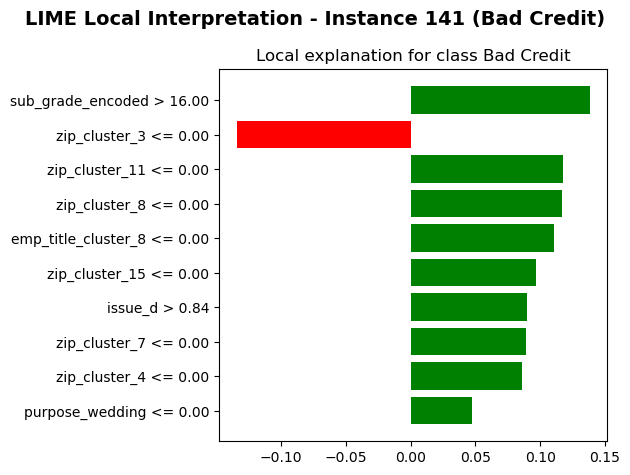

Successfully processed instance 141

 Successfully processed 4 instances
   Processed instances: [16, 323, 198863, 141]


{16: (<lime.explanation.Explanation at 0x2c2bec560>,
  [('zip_cluster_3 <= 0.00', -0.159466047665083),
   ('zip_cluster_8 <= 0.00', 0.13076007145588725),
   ('emp_title_cluster_8 <= 0.00', 0.09768881985172745),
   ('zip_cluster_11 <= 0.00', 0.09550027270407213),
   ('zip_cluster_15 <= 0.00', 0.09348338153403693),
   ('loan duration <= 0.00', -0.09108105367531538),
   ('zip_cluster_4 <= 0.00', 0.08565211573124898),
   ('purpose_renewable_energy <= 0.00', -0.07816913123779544),
   ('zip_cluster_7 <= 0.00', 0.07555007970274094),
   ('emp_title_cluster_2 <= 0.00', -0.06458125722534318)]),
 323: (<lime.explanation.Explanation at 0x2c2b33d40>,
  [('zip_cluster_3 <= 0.00', -0.14832445169631137),
   ('sub_grade_encoded > 16.00', 0.13738772486192735),
   ('zip_cluster_8 <= 0.00', 0.127890060461363),
   ('emp_title_cluster_8 <= 0.00', 0.09973334779238785),
   ('zip_cluster_11 <= 0.00', 0.09092814315801534),
   ('0.00 < loan duration <= 1.00', 0.09070799665591908),
   ('zip_cluster_4 <= 0.00', 0.

In [26]:
# Initialize and run the complete interpretability analysis
print("="*70)
print(" Initializing Credit Interpretability Analysis")
analyzer = CreditInterpretabilityAnalysis()

# Run comprehensive interpretability analysis
print("\n Running LIME Analysis...")

instance_idx_1 = np.array([16, 323, 198863,141])
analyzer.implement_lime_analysis(instance_idx=instance_idx_1, num_features=10)


 Initializing Credit Interpretability Analysis
Initializing interpretability analysis...


Model loaded: LGBMClassifier
 Training data: 524431 samples, 92 features
 Test data: 258793 samples
 Using temporal split: 2012-2015 → 2016

 LIME Explanation for test instance 48:
    Actual class: Bad Credit
    Predicted class: Bad Credit
   Prediction probability: [Good: 0.2171, Bad: 0.7829]

 Top 10 features according to LIME:
   ↘️ zip_cluster_3 <= 0.00: -0.1530
   ↗️ sub_grade_encoded > 16.00: +0.1376
   ↗️ zip_cluster_8 <= 0.00: +0.1283
   ↗️ emp_title_cluster_8 <= 0.00: +0.1002
   ↗️ zip_cluster_11 <= 0.00: +0.0926
   ↗️ 0.00 < loan duration <= 1.00: +0.0908
   ↗️ zip_cluster_4 <= 0.00: +0.0894
   ↗️ zip_cluster_7 <= 0.00: +0.0886
   ↗️ zip_cluster_15 <= 0.00: +0.0828
   ↗️ purpose_wedding <= 0.00: +0.0550


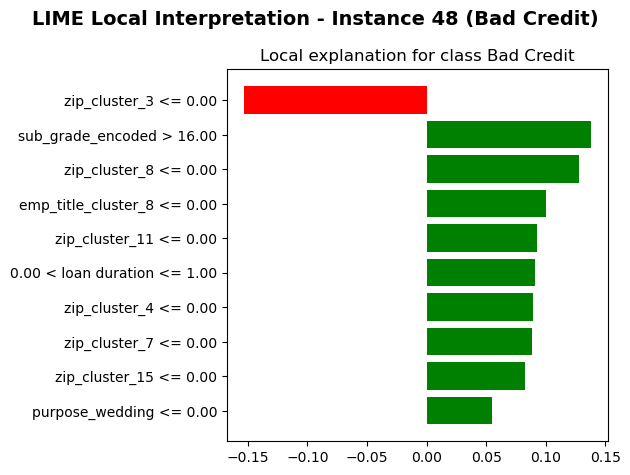

Successfully processed instance 48

 LIME Explanation for test instance 143:
    Actual class: Bad Credit
    Predicted class: Bad Credit
   Prediction probability: [Good: 0.2014, Bad: 0.7986]

 Top 10 features according to LIME:
   ↘️ zip_cluster_3 <= 0.00: -0.1499
   ↗️ sub_grade_encoded > 16.00: +0.1378
   ↗️ zip_cluster_8 <= 0.00: +0.1275
   ↗️ zip_cluster_11 <= 0.00: +0.0919
   ↗️ 0.00 < loan duration <= 1.00: +0.0908
   ↗️ zip_cluster_4 <= 0.00: +0.0887
   ↗️ zip_cluster_7 <= 0.00: +0.0878
   ↗️ issue_d > 0.84: +0.0846
   ↗️ zip_cluster_15 <= 0.00: +0.0821
   ↗️ purpose_wedding <= 0.00: +0.0535


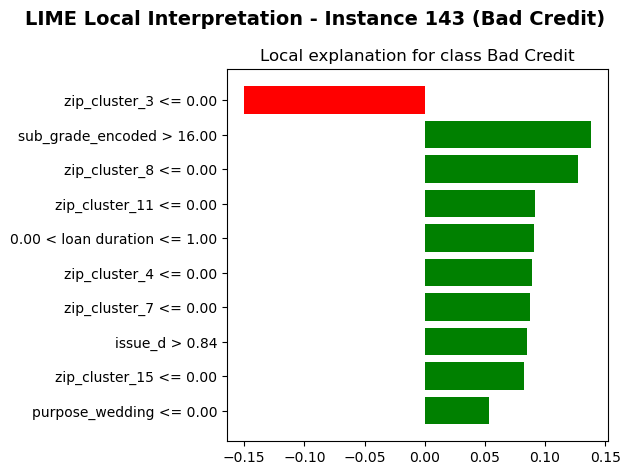

Successfully processed instance 143

 LIME Explanation for test instance 225:
    Actual class: Bad Credit
    Predicted class: Bad Credit
   Prediction probability: [Good: 0.1810, Bad: 0.8190]

 Top 10 features according to LIME:
   ↘️ zip_cluster_3 <= 0.00: -0.1938
   ↗️ issue_d > 0.84: +0.1476
   ↗️ zip_cluster_8 <= 0.00: +0.1297
   ↗️ emp_title_cluster_8 <= 0.00: +0.0988
   ↗️ zip_cluster_11 <= 0.00: +0.0988
   ↗️ zip_cluster_15 <= 0.00: +0.0947
   ↗️ 0.00 < loan duration <= 1.00: +0.0909
   ↗️ zip_cluster_4 <= 0.00: +0.0863
   ↗️ zip_cluster_7 <= 0.00: +0.0781
   ↘️ purpose_renewable_energy <= 0.00: -0.0775


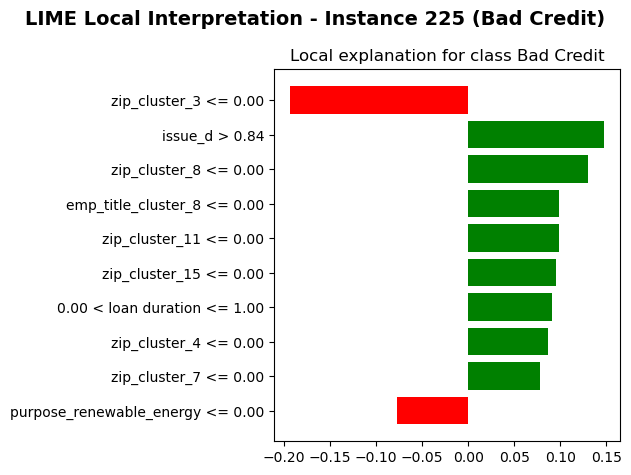

Successfully processed instance 225

 LIME Explanation for test instance 4:
    Actual class: Bad Credit
    Predicted class: Bad Credit
   Prediction probability: [Good: 0.2627, Bad: 0.7373]

 Top 10 features according to LIME:
   ↘️ zip_cluster_3 <= 0.00: -0.1464
   ↗️ sub_grade_encoded > 16.00: +0.1377
   ↗️ zip_cluster_8 <= 0.00: +0.1279
   ↗️ emp_title_cluster_8 <= 0.00: +0.0983
   ↗️ zip_cluster_11 <= 0.00: +0.0914
   ↘️ loan duration <= 0.00: -0.0903
   ↗️ zip_cluster_4 <= 0.00: +0.0895
   ↗️ zip_cluster_7 <= 0.00: +0.0869
   ↗️ zip_cluster_15 <= 0.00: +0.0805
   ↗️ purpose_wedding <= 0.00: +0.0542


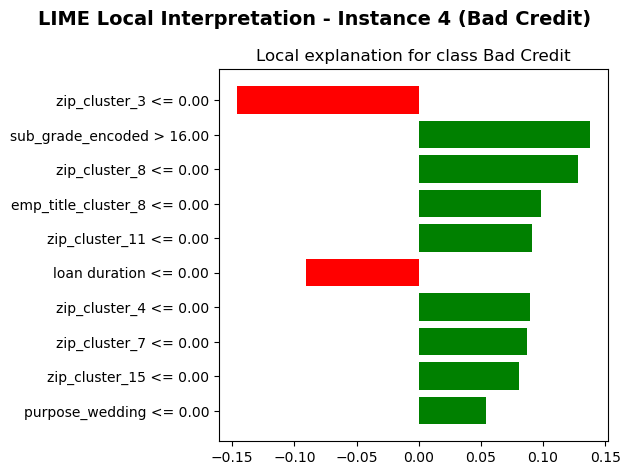

Successfully processed instance 4

 LIME Explanation for test instance 8:
    Actual class: Bad Credit
    Predicted class: Bad Credit
   Prediction probability: [Good: 0.4023, Bad: 0.5977]

 Top 10 features according to LIME:
   ↘️ zip_cluster_3 <= 0.00: -0.1483
   ↗️ sub_grade_encoded > 16.00: +0.1376
   ↗️ zip_cluster_8 <= 0.00: +0.1278
   ↗️ emp_title_cluster_8 <= 0.00: +0.1004
   ↗️ zip_cluster_11 <= 0.00: +0.0923
   ↘️ loan duration <= 0.00: -0.0905
   ↗️ zip_cluster_4 <= 0.00: +0.0893
   ↗️ zip_cluster_7 <= 0.00: +0.0881
   ↗️ zip_cluster_15 <= 0.00: +0.0826
   ↗️ purpose_wedding <= 0.00: +0.0544


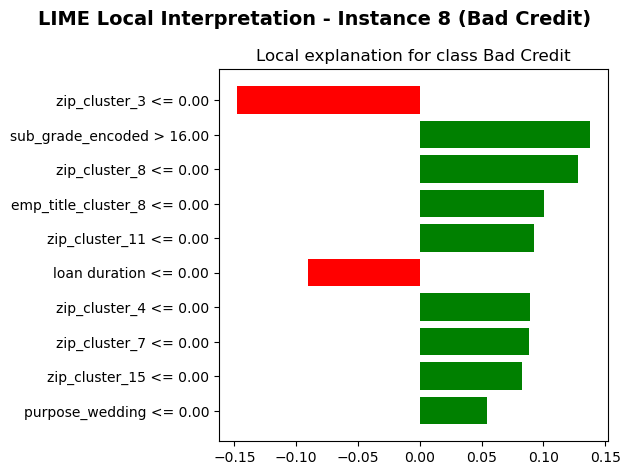

Successfully processed instance 8

 LIME Explanation for test instance 11:
    Actual class: Bad Credit
    Predicted class: Bad Credit
   Prediction probability: [Good: 0.3812, Bad: 0.6188]

 Top 10 features according to LIME:
   ↘️ zip_cluster_3 <= 0.00: -0.1659
   ↗️ zip_cluster_8 <= 0.00: +0.1323
   ↗️ zip_cluster_11 <= 0.00: +0.0984
   ↗️ emp_title_cluster_8 <= 0.00: +0.0982
   ↗️ zip_cluster_15 <= 0.00: +0.0932
   ↘️ loan duration <= 0.00: -0.0910
   ↗️ zip_cluster_4 <= 0.00: +0.0856
   ↘️ purpose_renewable_energy <= 0.00: -0.0793
   ↗️ zip_cluster_7 <= 0.00: +0.0786
   ↘️ emp_title_cluster_2 <= 0.00: -0.0640


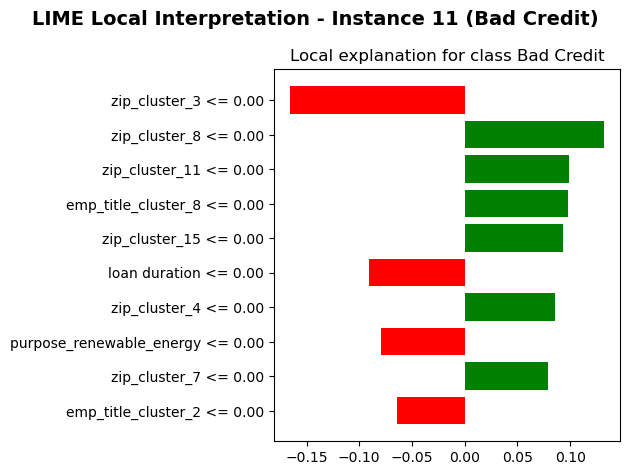

Successfully processed instance 11

 Successfully processed 6 instances
   Processed instances: [48, 143, 225, 4, 8, 11]


{48: (<lime.explanation.Explanation at 0x29de9c350>,
  [('zip_cluster_3 <= 0.00', -0.1530250638953901),
   ('sub_grade_encoded > 16.00', 0.13763426377075677),
   ('zip_cluster_8 <= 0.00', 0.12831402739703932),
   ('emp_title_cluster_8 <= 0.00', 0.10020514257691174),
   ('zip_cluster_11 <= 0.00', 0.09255506514489571),
   ('0.00 < loan duration <= 1.00', 0.09084750772760863),
   ('zip_cluster_4 <= 0.00', 0.08942930227399293),
   ('zip_cluster_7 <= 0.00', 0.08863358944964779),
   ('zip_cluster_15 <= 0.00', 0.08278844927920952),
   ('purpose_wedding <= 0.00', 0.055045580432514056)]),
 143: (<lime.explanation.Explanation at 0x29a71a1e0>,
  [('zip_cluster_3 <= 0.00', -0.14994113355313363),
   ('sub_grade_encoded > 16.00', 0.1378120540402999),
   ('zip_cluster_8 <= 0.00', 0.12747486305022138),
   ('zip_cluster_11 <= 0.00', 0.09188239896374606),
   ('0.00 < loan duration <= 1.00', 0.09082241250056709),
   ('zip_cluster_4 <= 0.00', 0.08872891374611307),
   ('zip_cluster_7 <= 0.00', 0.0877751707

In [27]:
"""
True Positive cases: [48, 143, 225]
False Negative cases: [4, 8, 11]
"""

# Initialize and run the complete interpretability analysis
print("="*70)
print(" Initializing Credit Interpretability Analysis")
analyzer = CreditInterpretabilityAnalysis()

instance_idx_2 = np.array([48, 143, 225, 4, 8, 11])
analyzer.implement_lime_analysis(instance_idx_2)


# Step 7 : Implement shap method for local interpretability


 Running SHAP Analysis...
Initializing interpretability analysis...
Model loaded: LGBMClassifier
 Training data: 524431 samples, 92 features
 Test data: 258793 samples
 Using temporal split: 2012-2015 → 2016
STEP 7: SHAP Analysis

Instance 16: Good Credit | Predicted: Good Credit | Prob: 0.345
Top 5 SHAP features:
  loan_to_income: -0.3225
  zip_cluster_14: -0.2480
  dti: -0.1537
  loan duration: -0.1373
  issue_d: +0.1125


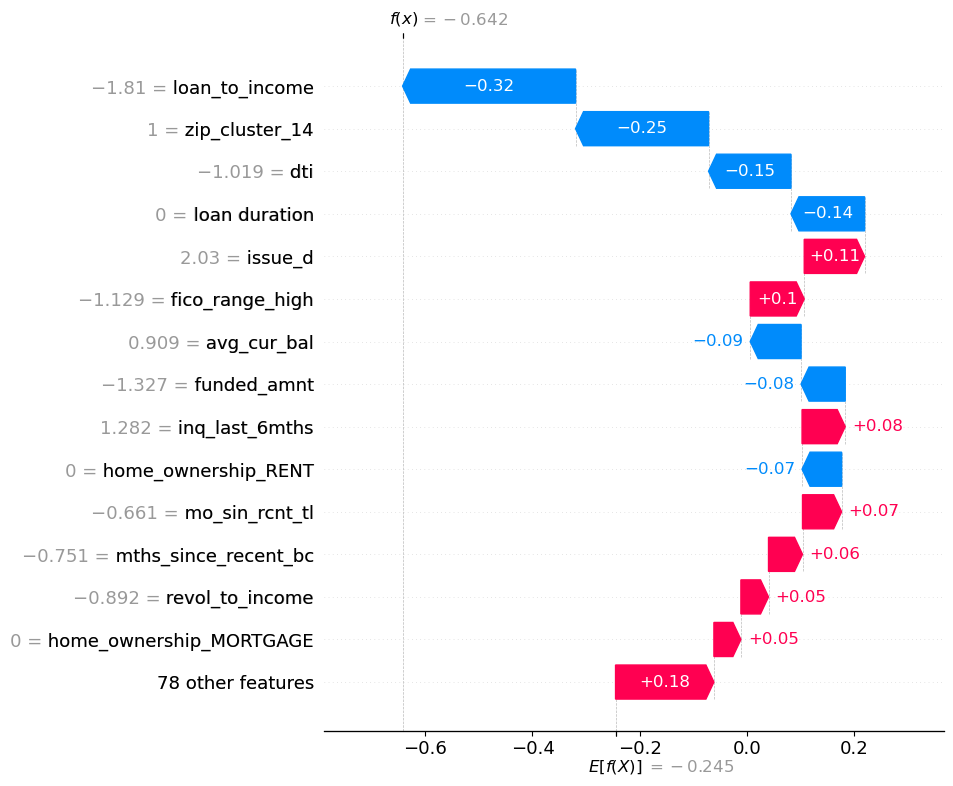


Instance 323: Good Credit | Predicted: Bad Credit | Prob: 0.689
Top 5 SHAP features:
  sub_grade_encoded: +0.4185
  loan duration: +0.2155
  issue_d: +0.1427
  grade_encoded: +0.1042
  inq_last_6mths: +0.0891


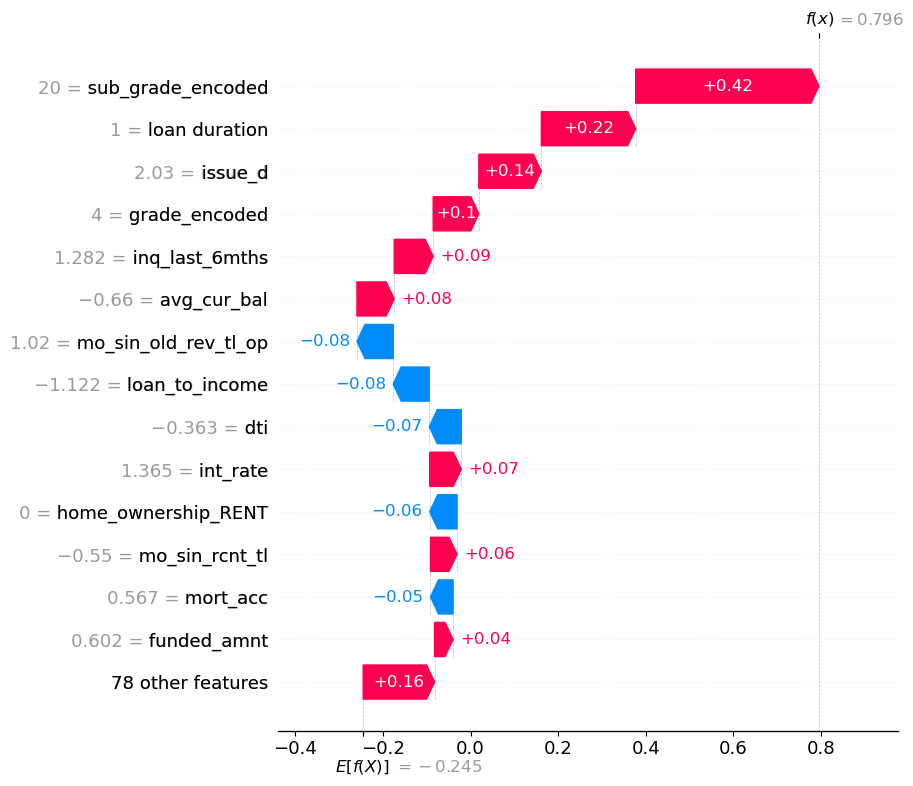


Instance 198863: Good Credit | Predicted: Good Credit | Prob: 0.413
Top 5 SHAP features:
  sub_grade_encoded: +0.2121
  dti: +0.1922
  loan duration: -0.1769
  fico_range_high: -0.1210
  home_ownership_RENT: -0.0906


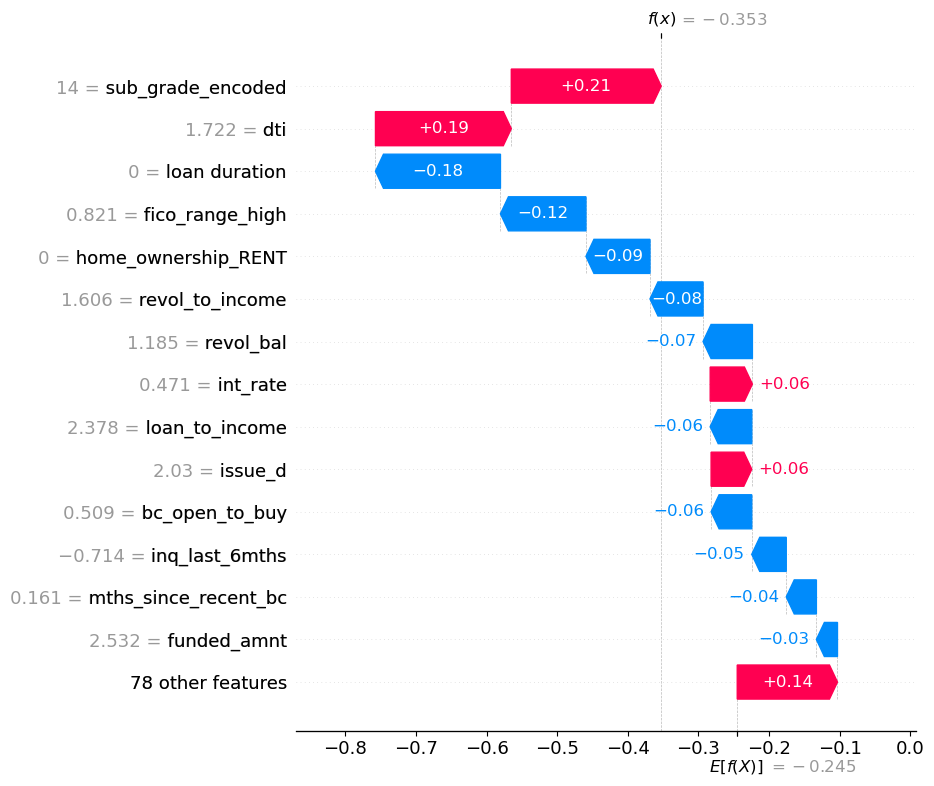


Instance 141: Bad Credit | Predicted: Bad Credit | Prob: 0.751
Top 5 SHAP features:
  sub_grade_encoded: +0.4549
  loan duration: +0.2262
  credit_age_diff: +0.2013
  mo_sin_old_rev_tl_op: +0.1592
  grade_encoded: +0.1101


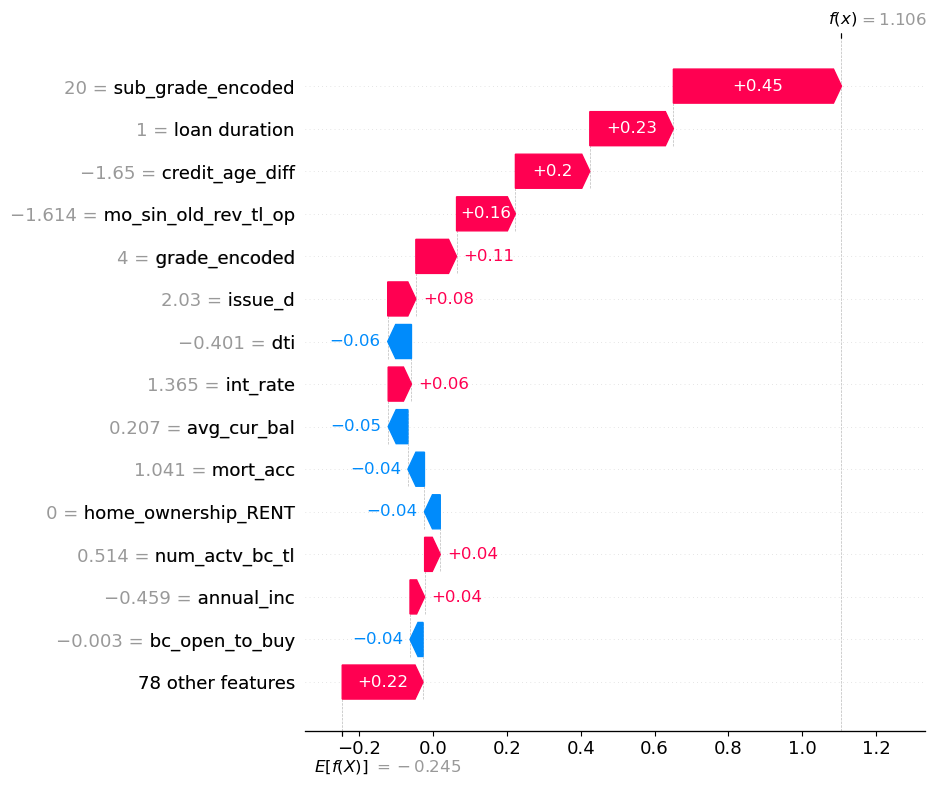

In [28]:

print("\n Running SHAP Analysis...")
instance_idx_1 = np.array([16, 323, 198863,141])
analyzer = CreditInterpretabilityAnalysis()
shap_results_dict = analyzer.implement_shap_analysis(instance_idx_1, max_display=15)



🔍 Running SHAP Analysis...
Initializing interpretability analysis...
Model loaded: LGBMClassifier
 Training data: 524431 samples, 92 features
 Test data: 258793 samples
 Using temporal split: 2012-2015 → 2016
STEP 7: SHAP Analysis

Instance 48: Bad Credit | Predicted: Bad Credit | Prob: 0.783
Top 5 SHAP features:
  sub_grade_encoded: +0.5682
  loan duration: +0.2147
  issue_d: +0.1431
  grade_encoded: +0.1338
  mo_sin_rcnt_tl: +0.0801


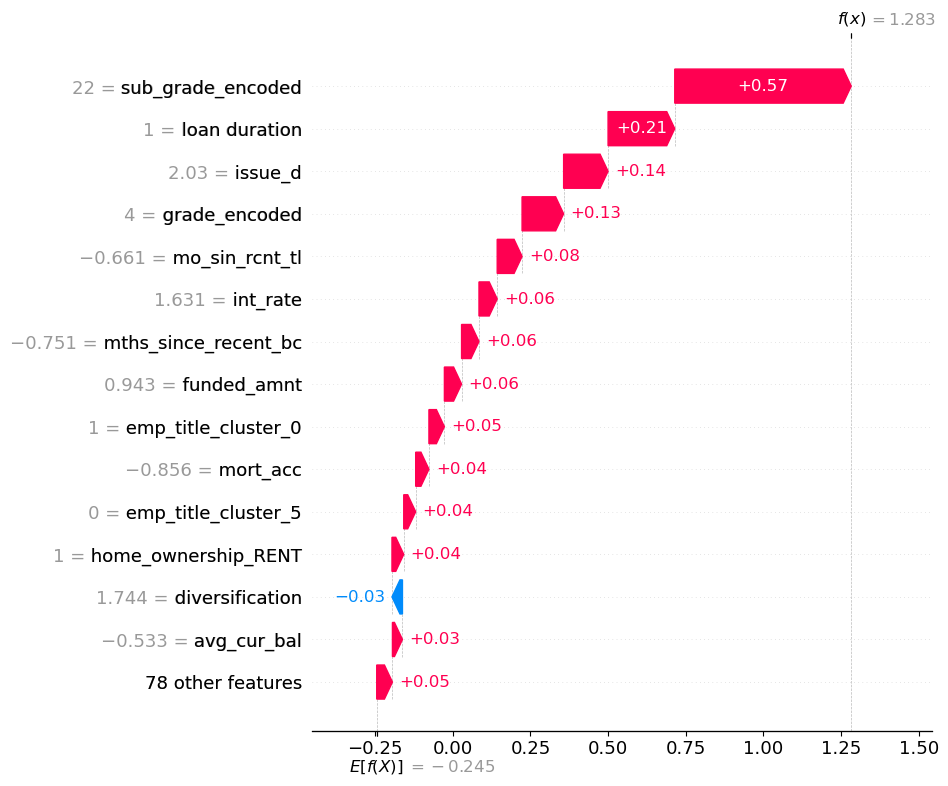


Instance 143: Bad Credit | Predicted: Bad Credit | Prob: 0.799
Top 5 SHAP features:
  sub_grade_encoded: +0.5139
  loan duration: +0.2203
  grade_encoded: +0.1183
  loan_to_income: +0.1157
  home_ownership_RENT: +0.1023


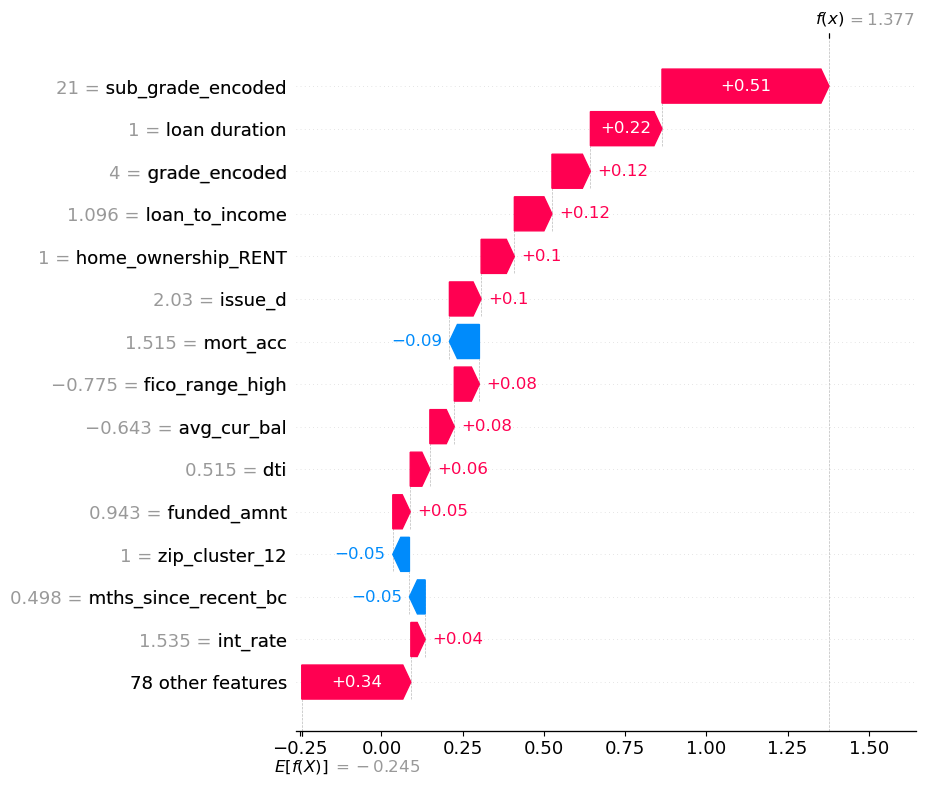


Instance 225: Bad Credit | Predicted: Bad Credit | Prob: 0.819
Top 5 SHAP features:
  sub_grade_encoded: +0.3638
  loan duration: +0.2865
  dti: +0.2661
  home_ownership_RENT: +0.1580
  issue_d: +0.1105


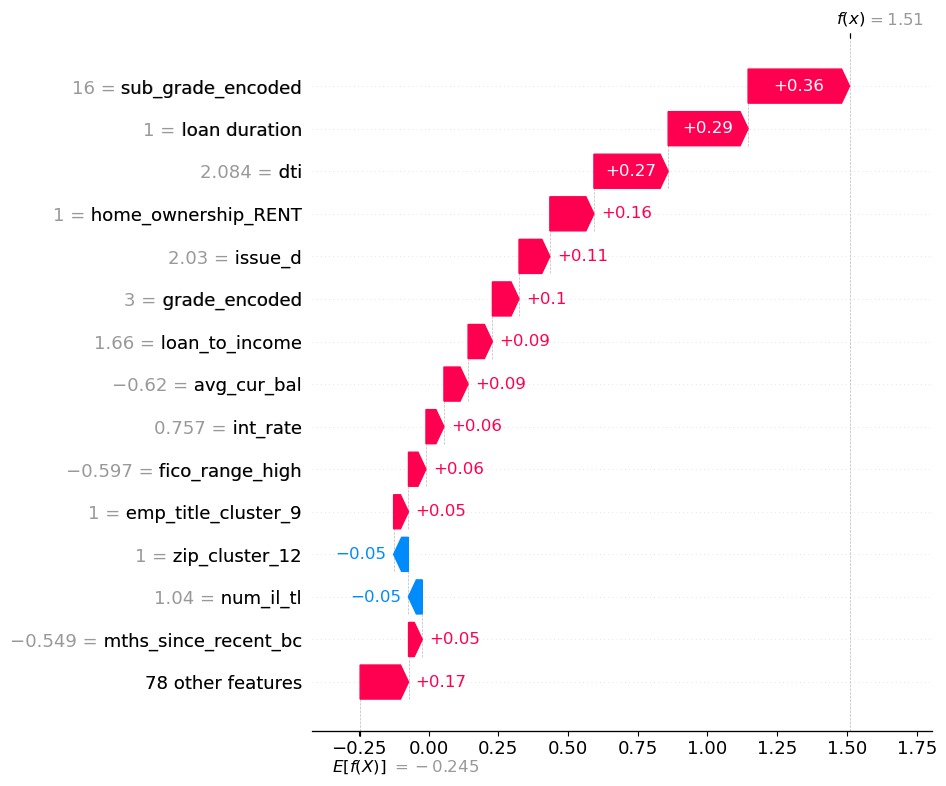


Instance 4: Bad Credit | Predicted: Bad Credit | Prob: 0.737
Top 5 SHAP features:
  sub_grade_encoded: +0.4387
  loan duration: -0.1917
  emp_title_cluster_7: +0.1242
  inq_last_6mths: +0.1224
  loan_to_income: +0.0966


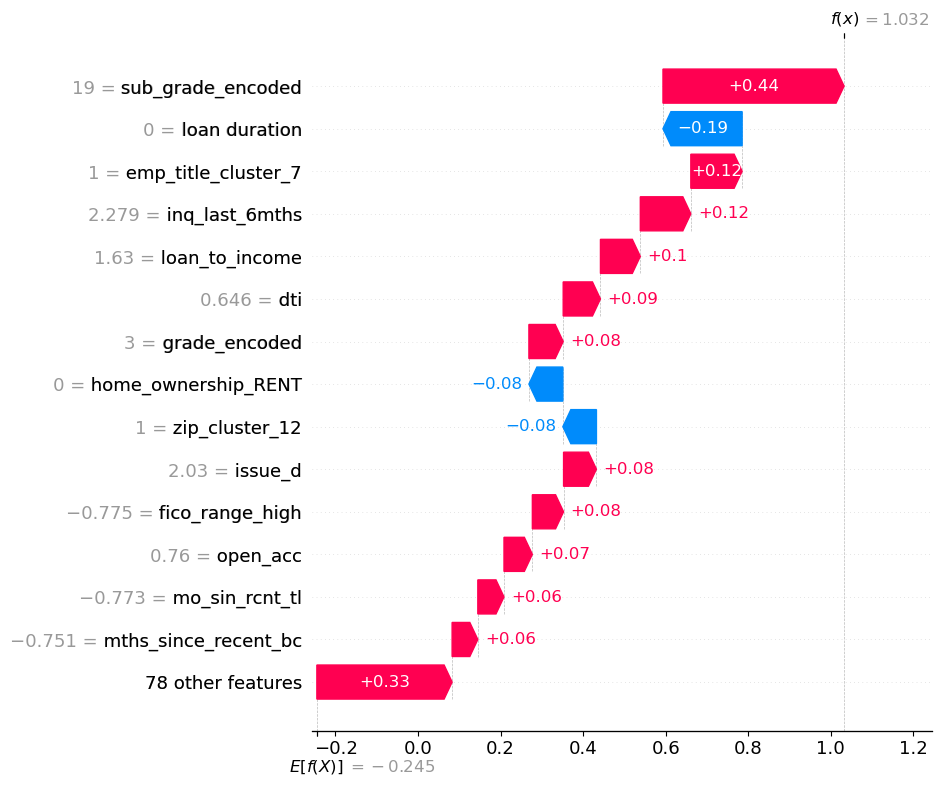


Instance 8: Bad Credit | Predicted: Bad Credit | Prob: 0.598
Top 5 SHAP features:
  sub_grade_encoded: +0.4246
  dti: +0.2127
  loan duration: -0.2102
  zip_cluster_14: -0.1885
  issue_d: +0.0971


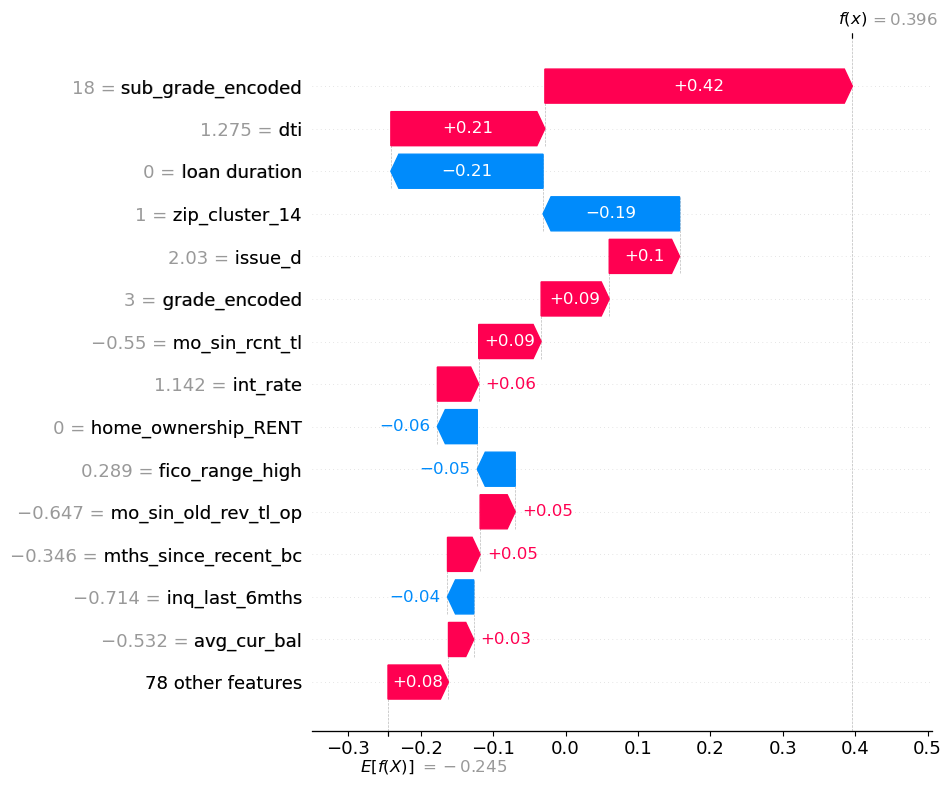


Instance 11: Bad Credit | Predicted: Bad Credit | Prob: 0.619
Top 5 SHAP features:
  zip_cluster_1: -0.1597
  bc_open_to_buy: +0.1542
  loan duration: -0.1401
  dti: +0.1385
  loan_to_income: +0.1025


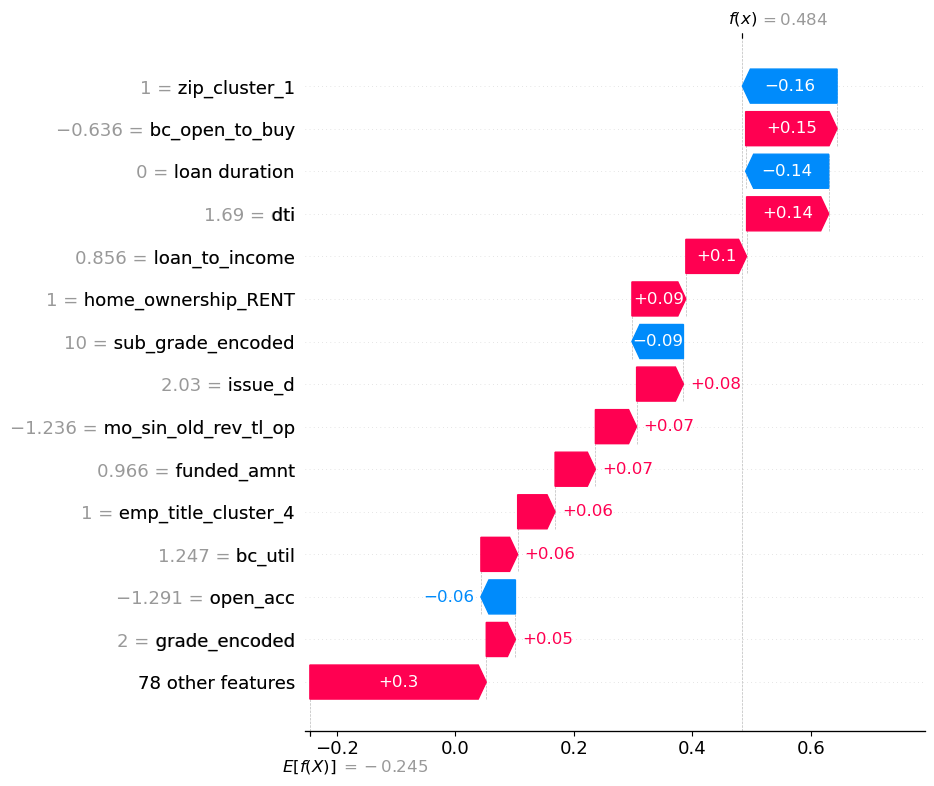

In [29]:
print("\n🔍 Running SHAP Analysis...")
instance_idx_2 = np.array([48, 143, 225, 4, 8, 11])
analyzer = CreditInterpretabilityAnalysis()
shap_results_dict = analyzer.implement_shap_analysis(instance_idx_2, max_display=15)

# Step 8 : Permutation importance method for performance interpretability

In [30]:
def run_permutation_importance(
    estimator, 
    X: pd.DataFrame, 
    y: pd.Series, 
    period_tag: str,
    n_repeats: int = 10, 
    random_state: int = 42,
    top_k_plot: int = 25
) -> pd.DataFrame:
    """
    Permutation Importance using ROC AUC as scoring.
    Saves: step8_permutation_importance_<period>.csv/.png
    """
    print(f"\n[Step 8] Permutation Importance (ROC AUC) — {period_tag}")
    result = permutation_importance(
        estimator, X, y,
        scoring="roc_auc",
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    features = X.columns if hasattr(X, "columns") else [f"f{i}" for i in range(X.shape[1])]
    df_pi = pd.DataFrame({
        "feature": features,
        "mean_drop": result.importances_mean,
        "std_drop": result.importances_std
    }).sort_values("mean_drop", ascending=False).reset_index(drop=True)

    csv_path = f"step8_permutation_importance_{period_tag}.csv"
    df_pi.to_csv(csv_path, index=False)

    k = min(top_k_plot, len(df_pi))
    plt.figure(figsize=(10, 6))
    plt.barh(df_pi["feature"].head(k)[::-1], df_pi["mean_drop"].head(k)[::-1])
    plt.xlabel("Mean AUC drop (higher = more important)")
    plt.ylabel("Feature")
    plt.title(f"Permutation Importance — {period_tag} (ROC AUC)")
    plt.tight_layout()
    png_path = f"step8_permutation_importance_{period_tag}.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved: {csv_path}, {png_path}")
    print("\nTop 10 drivers:")
    print(df_pi.head(10).to_string(index=False))
    return df_pi

# Run PI for both periods
pi_2016 = run_permutation_importance(
    estimator=lgbm_pipeline_fitted_2016, X=X_test, y=y_test, period_tag="2016"
)
pi_201920 = run_permutation_importance(
    estimator=lgbm_pipeline_fitted_201920, X=X_test_201920, y=y_test_201920, period_tag="2019_2020"
)



[Step 8] Permutation Importance (ROC AUC) — 2016


Saved: step8_permutation_importance_2016.csv, step8_permutation_importance_2016.png

Top 10 drivers:
             feature  mean_drop  std_drop
           sub_grade   0.048196  0.000596
       loan duration   0.016926  0.000282
         funded_amnt   0.012610  0.000208
                 dti   0.004900  0.000194
            int_rate   0.004724  0.000268
            zip_code   0.004251  0.000205
           revol_bal   0.003714  0.000220
      home_ownership   0.003566  0.000142
     fico_range_high   0.002631  0.000119
mo_sin_old_rev_tl_op   0.002388  0.000153

[Step 8] Permutation Importance (ROC AUC) — 2019_2020
Saved: step8_permutation_importance_2019_2020.csv, step8_permutation_importance_2019_2020.png

Top 10 drivers:
       feature  mean_drop  std_drop
      int_rate   0.052137  0.002456
   funded_amnt   0.041426  0.001581
      zip_code   0.007710  0.000653
     num_il_tl   0.006048  0.000431
           dti   0.005964  0.000690
home_ownership   0.005700  0.000558
    annual_inc   0.

# Step 9 : Assessing fairness of the model

In [31]:
DEPLOY_THRESHOLD = 0.78
PROTECTED_COL = "Pct_afro_american"  

def _safe_rate(num, den):
    return float(num) / float(den) if den and den > 0 else np.nan

def _format_interval_cats(cats, decimals=1):
    """Return string labels like '(0.0, 3.9]' with rounding."""
    return [f"({left:.{decimals}f}, {right:.{decimals}f}]" for left, right in zip(cats.left, cats.right)]

def bin_protected_attribute(
    s: pd.Series, 
    n_bins: int = 4, 
    strategy: str = "quantile",
    decimals: int = 1
) -> pd.Series:
    """
    Bin a (possibly continuous) protected attribute into ordered categorical bins.
    Labels are rounded like '(0.0, 3.9]'. Returns an *ordered* Categorical.
    """
    if s.dtype == "O" or str(s.dtype).startswith("category"):
        return s.astype("category")

    s = pd.to_numeric(s, errors="coerce")

    if strategy == "quantile":
        # Use qcut; fall back to cut if duplicates
        try:
            bins = pd.qcut(s, q=min(n_bins, s.nunique()), duplicates="drop")
        except Exception:
            bins = pd.cut(s, bins=min(n_bins, max(1, s.nunique())), include_lowest=True)
    else:
        bins = pd.cut(s, bins=n_bins, include_lowest=True)

    # Make labels rounded and ordered
    cats = bins.cat.categories
    labels = _format_interval_cats(cats, decimals=decimals)
    bins = bins.cat.rename_categories(labels)
    bins = bins.astype(pd.CategoricalDtype(categories=labels, ordered=True))
    return bins

def fairness_table_by_group(
    estimator,                 # fitted pipeline (sklearn Pipeline)
    X_test: pd.DataFrame,
    y_test: pd.Series,
    protected_binned: pd.Series,     # **ordered categorical** from bin_protected_attribute
    threshold: float = DEPLOY_THRESHOLD,
    group_name: str = "Pct_afro_american_binned",
) -> pd.DataFrame:
    """
    Per-group metrics: n, prevalence, selection_rate, TPR, FPR, Precision, AUC,
    selection_rate_ratio, passes_80pct_rule. Keeps group order from bins.
    """
    # Positional alignment
    Xp = X_test.reset_index(drop=True)
    yp = y_test.reset_index(drop=True)
    gp = protected_binned.reset_index(drop=True)

    # Ensure categorical & ordered
    if not pd.api.types.is_categorical_dtype(gp):
        gp = gp.astype("category")
    if getattr(gp.dtype, "ordered", False) is False:
        gp = gp.astype(pd.CategoricalDtype(categories=list(gp.cat.categories), ordered=True))

    proba = estimator.predict_proba(Xp)[:, 1]
    y_pred = (proba >= threshold).astype(int)

    df = pd.DataFrame({"group": gp, "y": yp.values, "proba": proba, "y_pred": y_pred})

    rows = []
    # groupby with sort=False to respect categorical order
    for g, sub in df.groupby("group", sort=False, observed=True):
        n = len(sub)
        pos = int(sub["y"].sum())
        neg = n - pos
        tp = int(((sub["y"] == 1) & (sub["y_pred"] == 1)).sum())
        fp = int(((sub["y"] == 0) & (sub["y_pred"] == 1)).sum())

        prevalence = _safe_rate(pos, n)
        selection_rate = _safe_rate(tp + fp, n)
        tpr = _safe_rate(tp, pos)
        fpr = _safe_rate(fp, neg)
        precision = _safe_rate(tp, tp + fp)

        try:
            auc_g = roc_auc_score(sub["y"], sub["proba"]) if sub["y"].nunique() == 2 else np.nan
        except Exception:
            auc_g = np.nan

        rows.append({
            "group": str(g), "n": n, "prevalence": prevalence, "selection_rate": selection_rate,
            "TPR": tpr, "FPR": fpr, "Precision": precision, "AUC": auc_g
        })

    out = pd.DataFrame(rows)
    # Reapply order on the string labels
    ordered_labels = [str(c) for c in gp.cat.categories]
    out["group"] = pd.Categorical(out["group"], categories=ordered_labels, ordered=True)
    out = out.sort_values("group").reset_index(drop=True)

    max_sr = out["selection_rate"].max() if len(out) else 0.0
    out["selection_rate_ratio"] = out["selection_rate"] / max_sr if max_sr > 0 else np.nan
    out["passes_80pct_rule"] = out["selection_rate_ratio"] >= 0.8
    out.insert(0, "protected_attribute", group_name)
    return out

def run_fairness_step9_for_period(
    estimator,                 # fitted pipeline
    X_test: pd.DataFrame,
    y_test: pd.Series,
    raw_df_for_same_rows: pd.DataFrame,  # aligned to X_test rows (same order/length)
    pct_col: str = PROTECTED_COL,
    threshold: float = DEPLOY_THRESHOLD,
    n_bins: int = 4,
    strategy: str = "quantile",
    period_tag: str = "2016"
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Computes fairness metrics for one period and saves CSV with step9_ prefix.
    """
    if pct_col not in raw_df_for_same_rows.columns:
        raise ValueError(f"Column '{pct_col}' not found. Columns sample: {list(raw_df_for_same_rows.columns)[:10]} ...")

    # Align
    Xp = X_test.reset_index(drop=True)
    yp = y_test.reset_index(drop=True)
    prot = raw_df_for_same_rows[pct_col].reset_index(drop=True)

    if len(Xp) != len(prot):
        raise ValueError(
            f"Length mismatch: X_test={len(Xp)} vs protected={len(prot)}. "
            f"Ensure raw_df_for_same_rows matches the same test subset and order."
        )

    # **Create ordered categorical bins with rounded labels**
    binned = bin_protected_attribute(prot, n_bins=n_bins, strategy=strategy, decimals=1)

    fair_df = fairness_table_by_group(
        estimator=estimator,
        X_test=Xp,
        y_test=yp,
        protected_binned=binned,
        threshold=threshold,
        group_name=f"{pct_col}_binned"
    )

    csv_name = f"step9_fairness_{period_tag}.csv"
    fair_df.to_csv(csv_name, index=False)
    print(f"\nSaved Step 9 table for {period_tag}: {csv_name}")
    counts = fair_df[["group", "n"]].copy()
    return fair_df, counts

# Prepare raw test frames aligned to X_test rows
raw_test_2016 = (og_df_val_1.loc[X_test.index]
                 if set(X_test.index).issubset(set(og_df_val_1.index)) else og_df_val_1).reset_index(drop=True)
raw_test_201920 = (og_df_test_stab.loc[X_test_201920.index]
                   if set(X_test_201920.index).issubset(set(og_df_test_stab.index)) else og_df_test_stab).reset_index(drop=True)

# Run Step 9 for both periods
fair_2016, counts_2016 = run_fairness_step9_for_period(
    estimator=lgbm_pipeline_fitted_2016,
    X_test=X_test, y_test=y_test,
    raw_df_for_same_rows=raw_test_2016,
    pct_col=PROTECTED_COL, threshold=DEPLOY_THRESHOLD,
    n_bins=4, strategy="quantile", period_tag="2016"
)

fair_201920, counts_201920 = run_fairness_step9_for_period(
    estimator=lgbm_pipeline_fitted_201920,
    X_test=X_test_201920, y_test=y_test_201920,
    raw_df_for_same_rows=raw_test_201920,
    pct_col=PROTECTED_COL, threshold=DEPLOY_THRESHOLD,
    n_bins=4, strategy="quantile", period_tag="2019_2020"
)

print("\n[Step 9] Fairness — 2016")
print(fair_2016.to_string(index=False))
print("\n[Step 9] Fairness — 2019-2020")
print(fair_201920.to_string(index=False))


# Fairness plots 


def plot_fairness_results(fair_df, period_tag):
    """
    Create fairness visuals for selection rate, TPR/FPR, and AUC.
    Uses the categorical order of 'group' so bars are left→right by bin range.
    Saves PNGs with step9_ prefix.
    """
    # Ensure 'group' is categorical & ordered if present as strings
    if not pd.api.types.is_categorical_dtype(fair_df["group"]):
        # try to infer order from sorted unique labels like '(a, b]'
        ordered_groups = sorted(fair_df["group"].unique(),
                                key=lambda lab: float(lab.strip("()[]").split(",")[0]))
        fair_df = fair_df.copy()
        fair_df["group"] = pd.Categorical(fair_df["group"],
                                          categories=ordered_groups, ordered=True)

    order = list(fair_df["group"].cat.categories)

    # 1) Selection Rate
    plt.figure(figsize=(8,5))
    sns.barplot(data=fair_df, x="group", y="selection_rate", order=order, color="tab:blue")
    if fair_df["selection_rate"].notna().any():
        plt.axhline(fair_df["selection_rate"].max()*0.8, color="red", linestyle="--", label="80% rule threshold")
    plt.title(f"Selection Rate by Group ({period_tag})")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Selection Rate")
    plt.xlabel("Ethnicity groups (increasing %)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"step9_fairness_selection_rate_{period_tag}.png", dpi=300, bbox_inches="tight")
    plt.close()

    # 2) TPR/FPR
    plt.figure(figsize=(8,5))
    fair_df_melt = fair_df.melt(id_vars=["group"], value_vars=["TPR","FPR"], 
                                var_name="Metric", value_name="Rate")
    sns.barplot(data=fair_df_melt, x="group", y="Rate", hue="Metric", order=order)
    plt.title(f"TPR / FPR by Group ({period_tag})")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Rate")
    plt.xlabel("Ethnicity groups (increasing %)")
    plt.tight_layout()
    plt.savefig(f"step9_fairness_tpr_fpr_{period_tag}.png", dpi=300, bbox_inches="tight")
    plt.close()

    # 3) AUC
    plt.figure(figsize=(8,5))
    sns.barplot(data=fair_df, x="group", y="AUC", order=order, color="tab:green")
    plt.title(f"AUC by Group ({period_tag})")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("AUC")
    plt.xlabel("Ethnicity groups (increasing %)")
    plt.ylim(0.0, 1.0)
    plt.tight_layout()
    plt.savefig(f"step9_fairness_auc_{period_tag}.png", dpi=300, bbox_inches="tight")
    plt.close()

    print(f" Saved Step 9 fairness visuals for {period_tag}")

# Generate plots for both periods
plot_fairness_results(fair_2016, "2016")
plot_fairness_results(fair_201920, "2019_2020")

# Optional: quick cross-period comparison of selection-rate ratio
try:
    sr_ratio_2016 = fair_2016["selection_rate_ratio"].min()
    sr_ratio_201920 = fair_201920["selection_rate_ratio"].min()
    print(f"\nSelection-rate ratio (min group / max group): 2016={sr_ratio_2016:.3f}, 2019-2020={sr_ratio_201920:.3f}")
except Exception:
    pass



Saved Step 9 table for 2016: step9_fairness_2016.csv

Saved Step 9 table for 2019_2020: step9_fairness_2019_2020.csv

[Step 9] Fairness — 2016
     protected_attribute        group     n  prevalence  selection_rate      TPR      FPR  Precision      AUC  selection_rate_ratio  passes_80pct_rule
Pct_afro_american_binned   (0.0, 4.0] 65110    0.206297        0.036569 0.101697 0.019641   0.573709 0.715696              0.824469               True
Pct_afro_american_binned   (4.0, 8.9] 65093    0.203509        0.035211 0.098513 0.019037   0.569372 0.719046              0.793858              False
Pct_afro_american_binned  (8.9, 18.8] 64132    0.213185        0.039575 0.108909 0.020789   0.586682 0.716370              0.892236               True
Pct_afro_american_binned (18.8, 70.4] 64458    0.217521        0.044354 0.119606 0.023435   0.586569 0.719390              1.000000               True

[Step 9] Fairness — 2019-2020
     protected_attribute        group    n  prevalence  selection_rate

# Step 10 : implementing a FPDP using a fairness measure.

In [32]:
withLgbmDPandTarget_df = withLgbmDP_df.join(full_df[['target']], how='left')
threshold = 0.78
withLgbmDPandTarget_df['pred_binary'] = (withLgbmDPandTarget_df['Predicted probabilities'] >= threshold).astype(int)
withLgbmDPandTarget_df['Pct_afro_bin'] = pd.qcut(
    withLgbmDPandTarget_df['Pct_afro_american'], 
    q=4, 
    labels=False
)

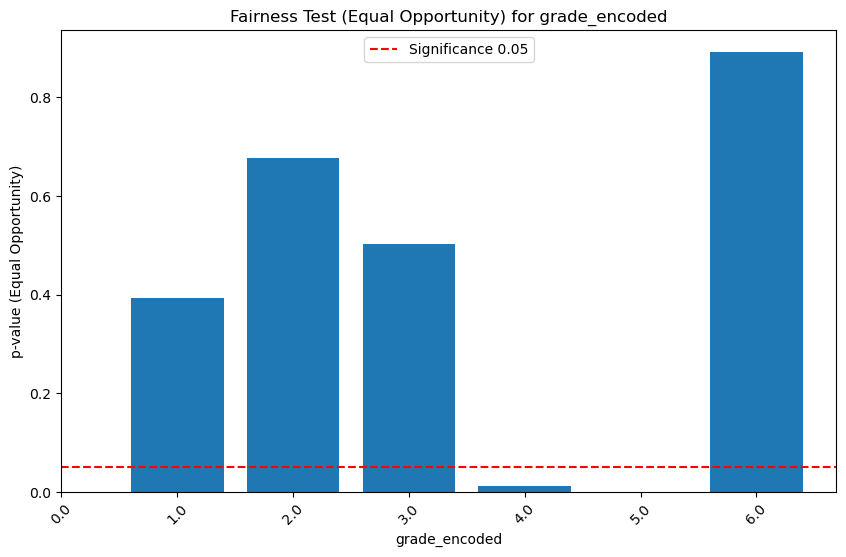

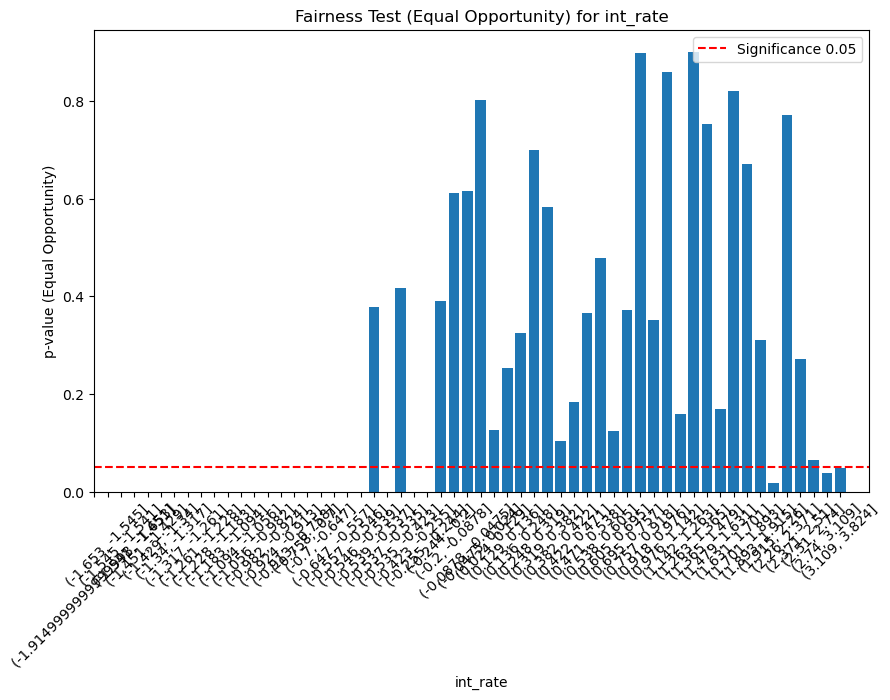

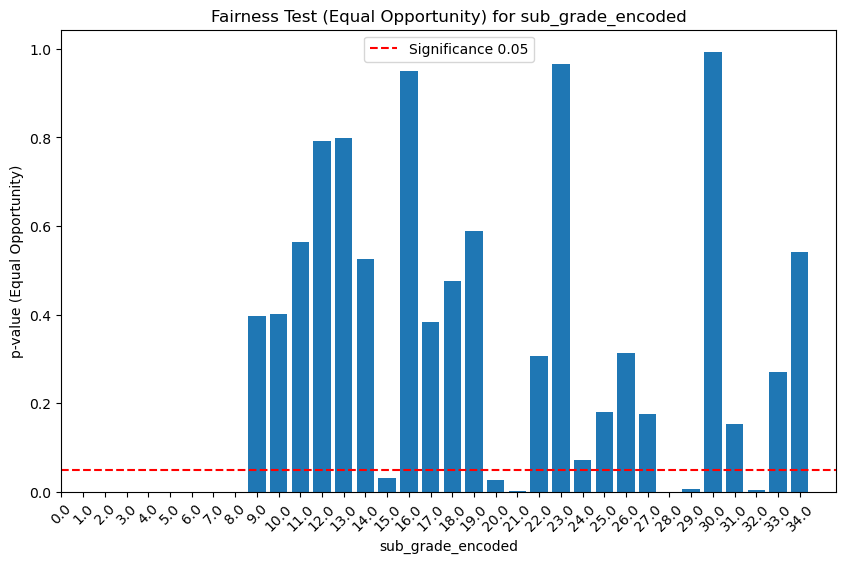

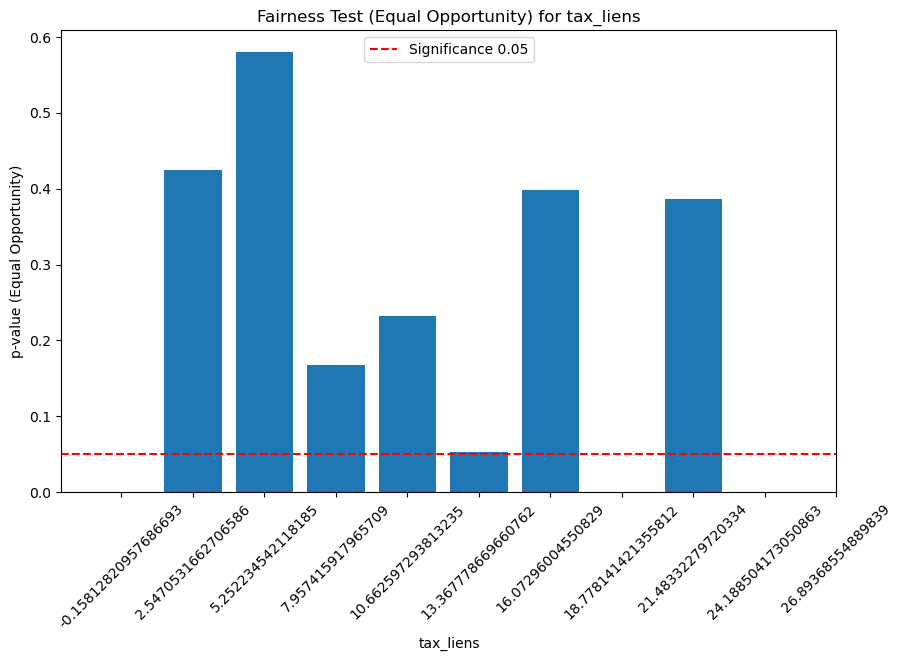

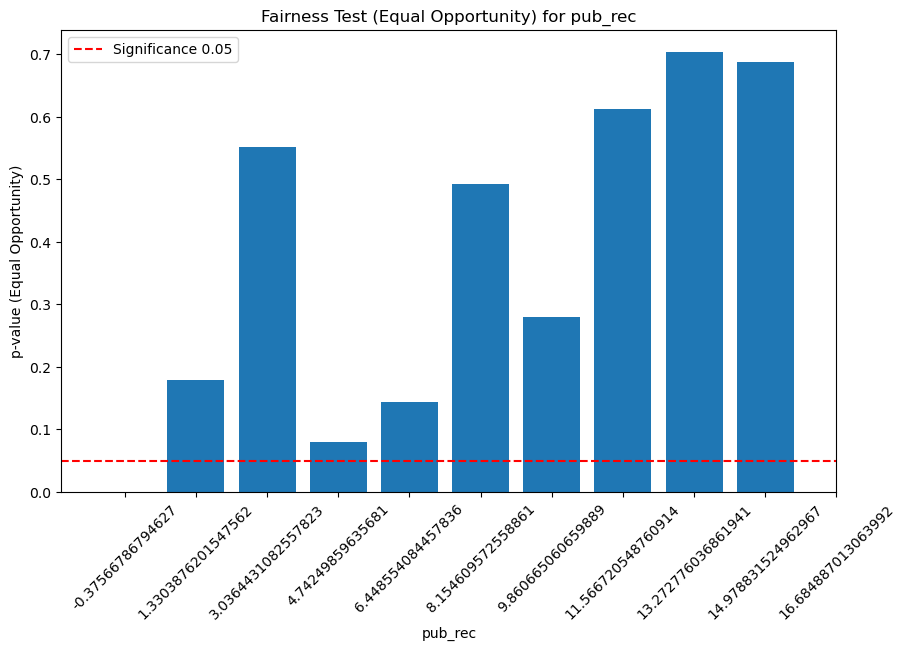

In [33]:
def eo_pvalue(feature):

    df = withLgbmDPandTarget_df.copy()
    
    # if continuous feature, manage bins
    if pd.api.types.is_numeric_dtype(df[feature]) and df[feature].nunique() > 100:
        df[feature+'_bin'] = pd.qcut(df[feature], q=100, duplicates='drop')
        levels = df[feature+'_bin'].unique()
        feature_col = feature+'_bin'
    else:
        feature_col = feature
        levels = df[feature].unique()
    
    p_values = {}

    # Testing inside each feature bins /level 
    for level in sorted(levels):
        df_level = df[df[feature_col] == level]
        df_tp = df_level[df_level['target'] == 1]  # EO 
        
        # check enough fata
        if df_tp['pred_binary'].nunique() < 2 or len(df_tp) < 5 :
            p_values[level] = np.nan
            continue
        
        contingency = pd.crosstab(df_tp['Pct_afro_bin'], df_tp['pred_binary'])
        if (contingency.sum(axis=1) == 0).any():
            p_values[level] = np.nan
            continue
        # Chi-squared test
        _, p, _, _ = chi2_contingency(contingency)
        p_values[level] = p
    
    return p_values


def plot_eo_pvalues(p_values, feature_name):
    plt.figure(figsize=(10,6))
    plt.bar(range(len(p_values)), list(p_values.values()), tick_label=[str(l) for l in p_values.keys()])
    plt.axhline(y=0.05, color='r', linestyle='--', label='Significance 0.05')
    plt.xlabel(feature_name)
    plt.ylabel('p-value (Equal Opportunity)')
    plt.title(f'Fairness Test (Equal Opportunity) for {feature_name}')
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

features_to_test = ['grade_encoded', 'int_rate', 'sub_grade_encoded','tax_liens','pub_rec']
for feat in features_to_test:
    pvals = eo_pvalue(feat)
    plot_eo_pvalues(pvals, feat)

With this chi squared test we are testing the null hypothesis that given the level of a certain feature, the predicted outcome and the sensitive attribute are independent. Then if p-value is <0.05 the null hypothesis is rejected meaning this feature is a candidate feature explaining model unfairness. Thus for instance, we see that pub_rec and tax_liens are not candidate variables while int_rate and grade_encoded are.